In [1]:
# ============================================================
# RQ1 Reproducibility Script
# Speed profiling across emulator testing styles
# Base = instrumentation-executed + first attempt + usable verdict
#
# Reads:
#   D:\0.1-Data_Mar18_V20.0\MainDataset.csv
#
# Writes:
#   D:\0.1-Data_Mar18_V20.0\RQ1\
#       - rq1_base_counts.csv
#       - rq1_medians_and_support.csv
#       - rq1_overall_kw.csv
#       - rq1_pairwise_stats.csv
#       - rq1_summary.txt
#
# Notes:
# - Usable verdict = run_conclusion in {"success", "failure"}
# - Layer 2 uses the selected stage3 columns
# ============================================================

from __future__ import annotations

import itertools
import math
import os
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu


# -----------------------------
# Paths
# -----------------------------
INPUT_DIR = Path(r"D:\0.1-Data_Mar18_V20.0")
INPUT_CSV = INPUT_DIR / "MainDataset.csv"
OUTPUT_DIR = INPUT_DIR / "RQ1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# -----------------------------
# Study setup
# -----------------------------
STYLE_ORDER = ["Community", "Custom", "GMD", "Third-Party"]
USABLE_VERDICTS = {"success", "failure"}

OUTCOMES = {
    "Run duration": "study_run_duration_seconds",
    "Layer1 time to instrumentation envelope": "study_layer1_time_to_instrumentation_envelope_seconds",
    "Layer1 instrumentation job envelope": "study_layer1_instrumentation_job_envelope_seconds",
    "Layer1 post-instrumentation tail": "study_layer1_post_instrumentation_tail_seconds",
    "Layer2 pre-invocation": "study_pre_invocation_selected_stage3_seconds",
    "Layer2 invocation execution window": "study_invocation_execution_window_selected_stage3_seconds",
    "Layer2 post-invocation": "study_post_invocation_selected_stage3_seconds",
}


# -----------------------------
# Helper functions
# -----------------------------
def cliffs_delta(x: np.ndarray, y: np.ndarray) -> float:
    """
    Cliff's delta using rank-based Mann-Whitney relation:
    delta = 2U / (n1*n2) - 1
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan

    # Use scipy U statistic
    u_stat, _ = mannwhitneyu(x, y, alternative="two-sided")
    return (2.0 * u_stat / (len(x) * len(y))) - 1.0


def delta_magnitude(delta: float) -> str:
    """
    Romano-style rough interpretation.
    """
    if pd.isna(delta):
        return "NA"
    ad = abs(delta)
    if ad < 0.147:
        return "negligible"
    if ad < 0.33:
        return "small"
    if ad < 0.474:
        return "small-to-medium"
    return "medium-or-larger"


def epsilon_squared_from_kruskal(H: float, k: int, n: int) -> float:
    """
    Epsilon-squared for Kruskal-Wallis.
    Common form: (H - k + 1) / (n - k)
    """
    if n <= k:
        return np.nan
    return max(0.0, (H - k + 1.0) / (n - k))


def holm_adjust(pvals: List[float]) -> List[float]:
    """
    Holm correction.
    """
    m = len(pvals)
    indexed = sorted(enumerate(pvals), key=lambda t: t[1])
    adjusted = [None] * m

    running_max = 0.0
    for rank, (idx, p) in enumerate(indexed, start=1):
        adj = (m - rank + 1) * p
        running_max = max(running_max, adj)
        adjusted[idx] = min(running_max, 1.0)

    return adjusted


def fmt_p(p: float) -> str:
    if pd.isna(p):
        return "NA"
    if p < 1e-4:
        return f"{p:.2e}"
    return f"{p:.4f}"


def fmt_num(x: float) -> str:
    if pd.isna(x):
        return "NA"
    return f"{x:.1f}"


# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(INPUT_CSV)

# -----------------------------
# Define Base under updated methodology
# -----------------------------
base = df[
    (df["controller_instru_job_count_gt0"] == True)
    & (df["controller_attempt_eq_1"] == True)
    & (df["run_conclusion"].isin(USABLE_VERDICTS))
].copy()

# Optional style scope safety
base = base[base["style"].isin(STYLE_ORDER)].copy()

# -----------------------------
# 1) Base counts
# -----------------------------
base_counts = (
    base.groupby("style", dropna=False)
    .size()
    .reindex(STYLE_ORDER, fill_value=0)
    .reset_index(name="n_base")
)

base_counts.to_csv(OUTPUT_DIR / "rq1_base_counts.csv", index=False)

# -----------------------------
# 2) Medians and support counts
# -----------------------------
median_rows = []
for outcome_label, col in OUTCOMES.items():
    for style in STYLE_ORDER:
        s = base.loc[base["style"] == style, col].dropna()
        median_rows.append(
            {
                "outcome": outcome_label,
                "column": col,
                "style": style,
                "n_non_missing": int(s.shape[0]),
                "median": float(s.median()) if len(s) else np.nan,
                "iqr": float(s.quantile(0.75) - s.quantile(0.25)) if len(s) else np.nan,
                "p95": float(s.quantile(0.95)) if len(s) else np.nan,
            }
        )

medians_df = pd.DataFrame(median_rows)
medians_df.to_csv(OUTPUT_DIR / "rq1_medians_and_support.csv", index=False)

# -----------------------------
# 3) Overall multi-style tests
# -----------------------------
overall_rows = []
for outcome_label, col in OUTCOMES.items():
    grouped = []
    valid_styles = []
    for style in STYLE_ORDER:
        s = base.loc[base["style"] == style, col].dropna().to_numpy()
        if len(s) > 0:
            grouped.append(s)
            valid_styles.append(style)

    n_total = sum(len(g) for g in grouped)
    k = len(grouped)

    if k >= 2:
        H, p = kruskal(*grouped)
        eps2 = epsilon_squared_from_kruskal(H, k, n_total)
    else:
        H, p, eps2 = np.nan, np.nan, np.nan

    overall_rows.append(
        {
            "outcome": outcome_label,
            "column": col,
            "styles_included": ", ".join(valid_styles),
            "n_total_non_missing": n_total,
            "k_groups": k,
            "kruskal_H": H,
            "p_value": p,
            "epsilon_squared": eps2,
        }
    )

overall_df = pd.DataFrame(overall_rows)
overall_df.to_csv(OUTPUT_DIR / "rq1_overall_kw.csv", index=False)

# -----------------------------
# 4) Pairwise tests
# -----------------------------
pairwise_rows = []
for outcome_label, col in OUTCOMES.items():
    raw_pvals = []
    pair_meta = []

    for s1, s2 in itertools.combinations(STYLE_ORDER, 2):
        x = base.loc[base["style"] == s1, col].dropna().to_numpy()
        y = base.loc[base["style"] == s2, col].dropna().to_numpy()

        if len(x) == 0 or len(y) == 0:
            p = np.nan
            u = np.nan
            delta = np.nan
        else:
            u, p = mannwhitneyu(x, y, alternative="two-sided")
            delta = cliffs_delta(x, y)

        raw_pvals.append(p)
        pair_meta.append((s1, s2, len(x), len(y), u, delta))

    # Holm on non-NaN only
    valid_idx = [i for i, p in enumerate(raw_pvals) if not pd.isna(p)]
    valid_p = [raw_pvals[i] for i in valid_idx]
    valid_adj = holm_adjust(valid_p)

    adj_map = {i: np.nan for i in range(len(raw_pvals))}
    for idx, adj in zip(valid_idx, valid_adj):
        adj_map[idx] = adj

    for i, ((s1, s2, n1, n2, u, delta), raw_p) in enumerate(zip(pair_meta, raw_pvals)):
        pairwise_rows.append(
            {
                "outcome": outcome_label,
                "column": col,
                "style_1": s1,
                "style_2": s2,
                "n1": n1,
                "n2": n2,
                "median_1": base.loc[base["style"] == s1, col].dropna().median(),
                "median_2": base.loc[base["style"] == s2, col].dropna().median(),
                "mannwhitney_U": u,
                "p_value_raw": raw_p,
                "p_value_holm": adj_map[i],
                "cliffs_delta": delta,
                "delta_magnitude": delta_magnitude(delta),
            }
        )

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df.to_csv(OUTPUT_DIR / "rq1_pairwise_stats.csv", index=False)

# -----------------------------
# 5) Printed summary
# -----------------------------
summary_lines: List[str] = []
summary_lines.append("RQ1 reproducibility summary")
summary_lines.append("=" * 72)
summary_lines.append(f"Input file: {INPUT_CSV}")
summary_lines.append(f"Base size: {len(base):,}")
summary_lines.append("")
summary_lines.append("Base counts by style:")
for _, row in base_counts.iterrows():
    summary_lines.append(f"  - {row['style']}: {row['n_base']:,}")
summary_lines.append("")

summary_lines.append("Median timings by style")
summary_lines.append("-" * 72)
for outcome_label, col in OUTCOMES.items():
    summary_lines.append(f"{outcome_label} [{col}]")
    tmp = medians_df[medians_df["outcome"] == outcome_label].copy()
    for style in STYLE_ORDER:
        r = tmp[tmp["style"] == style].iloc[0]
        summary_lines.append(
            f"  {style:12s} n={int(r['n_non_missing']):5d}  "
            f"median={fmt_num(r['median']):>8s}  "
            f"IQR={fmt_num(r['iqr']):>8s}  "
            f"P95={fmt_num(r['p95']):>8s}"
        )
    overall_row = overall_df[overall_df["outcome"] == outcome_label].iloc[0]
    summary_lines.append(
        f"  Overall Kruskal-Wallis: H={overall_row['kruskal_H']:.3f}, "
        f"p={fmt_p(overall_row['p_value'])}, "
        f"epsilon^2={overall_row['epsilon_squared']:.4f}"
    )
    summary_lines.append("")

summary_lines.append("Selected pairwise results")
summary_lines.append("-" * 72)

# Print all pairwise in compact form
for outcome_label in OUTCOMES.keys():
    summary_lines.append(f"{outcome_label}")
    tmp = pairwise_df[pairwise_df["outcome"] == outcome_label].copy()
    for _, r in tmp.iterrows():
        summary_lines.append(
            f"  {r['style_1']} vs {r['style_2']}: "
            f"medians=({fmt_num(r['median_1'])}, {fmt_num(r['median_2'])}), "
            f"p_raw={fmt_p(r['p_value_raw'])}, "
            f"p_holm={fmt_p(r['p_value_holm'])}, "
            f"delta={r['cliffs_delta']:.3f} ({r['delta_magnitude']})"
        )
    summary_lines.append("")

summary_text = "\n".join(summary_lines)
print(summary_text)

with open(OUTPUT_DIR / "rq1_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("\nSaved outputs to:", OUTPUT_DIR)

RQ1 reproducibility summary
Input file: D:\0.1-Data_Mar18_V20.0\MainDataset.csv
Base size: 7,803

Base counts by style:
  - Community: 6,980
  - Custom: 34
  - GMD: 263
  - Third-Party: 526

Median timings by style
------------------------------------------------------------------------
Run duration [study_run_duration_seconds]
  Community    n= 6980  median=   877.0  IQR=  1492.8  P95= 13601.5
  Custom       n=   34  median=  1817.0  IQR=   874.0  P95=  3247.5
  GMD          n=  263  median=  1212.0  IQR=   154.0  P95=  1483.4
  Third-Party  n=  526  median=  1864.5  IQR=  1043.5  P95=34603064.5
  Overall Kruskal-Wallis: H=302.957, p=2.28e-65, epsilon^2=0.0385

Layer1 time to instrumentation envelope [study_layer1_time_to_instrumentation_envelope_seconds]
  Community    n= 6980  median=     4.0  IQR=   208.0  P95=  1645.0
  Custom       n=   34  median=     3.0  IQR=   313.2  P95=   599.6
  GMD          n=  263  median=     3.0  IQR=     1.0  P95=     7.0
  Third-Party  n=  526  media

In [ ]:
##RQ2

In [1]:
# ============================================================
# RQ2 Reproducibility Script
# Predictability and tail risk across emulator testing styles
# Base = instrumentation-executed + first attempt + usable verdict
#
# Reads:
#   D:\0.1-Data_Mar18_V20.0\MainDataset.csv
#
# Writes:
#   D:\0.1-Data_Mar18_V20.0\RQ2\
#       - rq2_base_counts.csv
#       - rq2_dispersion_summary.csv
#       - rq2_predictability_values_long.csv
#       - rq2_overall_kw.csv
#       - rq2_pairwise_stats.csv
#       - rq2_summary.txt
#
# Main predictability measure:
#   normalized absolute deviation from each style's own median
#   NAD = abs(x - median_style) / median_style
#
# Notes:
# - Usable verdict = run_conclusion in {"success", "failure"}
# - Layer 2 uses the selected stage3 columns
# ============================================================

from __future__ import annotations

import itertools
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu


# -----------------------------
# Paths
# -----------------------------
INPUT_DIR = Path(r"D:\0.1-Data_Mar18_V20.0")
INPUT_CSV = INPUT_DIR / "MainDataset.csv"
OUTPUT_DIR = INPUT_DIR / "RQ2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# -----------------------------
# Study setup
# -----------------------------
STYLE_ORDER = ["Community", "Custom", "GMD", "Third-Party"]
USABLE_VERDICTS = {"success", "failure"}

OUTCOMES = {
    "Run duration": "study_run_duration_seconds",
    "Layer1 time to instrumentation envelope": "study_layer1_time_to_instrumentation_envelope_seconds",
    "Layer1 instrumentation job envelope": "study_layer1_instrumentation_job_envelope_seconds",
    "Layer1 post-instrumentation tail": "study_layer1_post_instrumentation_tail_seconds",
    "Layer2 pre-invocation": "study_pre_invocation_selected_stage3_seconds",
    "Layer2 invocation execution window": "study_invocation_execution_window_selected_stage3_seconds",
    "Layer2 post-invocation": "study_post_invocation_selected_stage3_seconds",
}


# -----------------------------
# Helper functions
# -----------------------------
def cliffs_delta(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    u_stat, _ = mannwhitneyu(x, y, alternative="two-sided")
    return (2.0 * u_stat / (len(x) * len(y))) - 1.0


def delta_magnitude(delta: float) -> str:
    if pd.isna(delta):
        return "NA"
    ad = abs(delta)
    if ad < 0.147:
        return "negligible"
    if ad < 0.33:
        return "small"
    if ad < 0.474:
        return "small-to-medium"
    return "medium-or-larger"


def epsilon_squared_from_kruskal(H: float, k: int, n: int) -> float:
    if n <= k:
        return np.nan
    return max(0.0, (H - k + 1.0) / (n - k))


def holm_adjust(pvals: List[float]) -> List[float]:
    m = len(pvals)
    indexed = sorted(enumerate(pvals), key=lambda t: t[1])
    adjusted = [None] * m
    running_max = 0.0
    for rank, (idx, p) in enumerate(indexed, start=1):
        adj = (m - rank + 1) * p
        running_max = max(running_max, adj)
        adjusted[idx] = min(running_max, 1.0)
    return adjusted


def fmt_p(p: float) -> str:
    if pd.isna(p):
        return "NA"
    if p < 1e-4:
        return f"{p:.2e}"
    return f"{p:.4f}"


def fmt_num(x: float) -> str:
    if pd.isna(x):
        return "NA"
    return f"{x:.3f}"


def safe_ratio(num: float, den: float) -> float:
    if pd.isna(num) or pd.isna(den) or den == 0:
        return np.nan
    return num / den


# -----------------------------
# Load data and define Base
# -----------------------------
df = pd.read_csv(INPUT_CSV)

base = df[
    (df["controller_instru_job_count_gt0"] == True)
    & (df["controller_attempt_eq_1"] == True)
    & (df["run_conclusion"].isin(USABLE_VERDICTS))
].copy()

base = base[base["style"].isin(STYLE_ORDER)].copy()

# -----------------------------
# 1) Base counts
# -----------------------------
base_counts = (
    base.groupby("style", dropna=False)
    .size()
    .reindex(STYLE_ORDER, fill_value=0)
    .reset_index(name="n_base")
)
base_counts.to_csv(OUTPUT_DIR / "rq2_base_counts.csv", index=False)

# -----------------------------
# 2) Dispersion / tail summaries
# -----------------------------
disp_rows = []
for outcome_label, col in OUTCOMES.items():
    for style in STYLE_ORDER:
        s = base.loc[base["style"] == style, col].dropna()
        median = float(s.median()) if len(s) else np.nan
        iqr = float(s.quantile(0.75) - s.quantile(0.25)) if len(s) else np.nan
        p95 = float(s.quantile(0.95)) if len(s) else np.nan
        disp_rows.append(
            {
                "outcome": outcome_label,
                "column": col,
                "style": style,
                "n_non_missing": int(s.shape[0]),
                "median": median,
                "iqr": iqr,
                "p95": p95,
                "iqr_over_median": safe_ratio(iqr, median),
                "p95_over_median": safe_ratio(p95, median),
            }
        )

disp_df = pd.DataFrame(disp_rows)
disp_df.to_csv(OUTPUT_DIR / "rq2_dispersion_summary.csv", index=False)

# -----------------------------
# 3) Build normalized absolute deviation values
# -----------------------------
nad_rows = []
for outcome_label, col in OUTCOMES.items():
    for style in STYLE_ORDER:
        s = base.loc[base["style"] == style, ["style", col]].dropna().copy()
        if s.empty:
            continue
        median_style = s[col].median()
        if median_style == 0 or pd.isna(median_style):
            # Skip zero-median normalization to avoid undefined values
            continue
        s["outcome"] = outcome_label
        s["column"] = col
        s["style_median"] = median_style
        s["nad"] = (s[col] - median_style).abs() / median_style
        nad_rows.append(s[["outcome", "column", "style", col, "style_median", "nad"]])

nad_long = pd.concat(nad_rows, ignore_index=True)
nad_long.to_csv(OUTPUT_DIR / "rq2_predictability_values_long.csv", index=False)

# -----------------------------
# 4) Overall Kruskal-Wallis on NAD
# -----------------------------
overall_rows = []
for outcome_label, col in OUTCOMES.items():
    tmp = nad_long[nad_long["outcome"] == outcome_label].copy()

    grouped = []
    valid_styles = []
    for style in STYLE_ORDER:
        s = tmp.loc[tmp["style"] == style, "nad"].dropna().to_numpy()
        if len(s) > 0:
            grouped.append(s)
            valid_styles.append(style)

    n_total = sum(len(g) for g in grouped)
    k = len(grouped)

    if k >= 2:
        H, p = kruskal(*grouped)
        eps2 = epsilon_squared_from_kruskal(H, k, n_total)
    else:
        H, p, eps2 = np.nan, np.nan, np.nan

    overall_rows.append(
        {
            "outcome": outcome_label,
            "column": col,
            "styles_included": ", ".join(valid_styles),
            "n_total_non_missing": n_total,
            "k_groups": k,
            "kruskal_H": H,
            "p_value": p,
            "epsilon_squared": eps2,
        }
    )

overall_df = pd.DataFrame(overall_rows)
overall_df.to_csv(OUTPUT_DIR / "rq2_overall_kw.csv", index=False)

# -----------------------------
# 5) Pairwise Mann-Whitney on NAD
# -----------------------------
pairwise_rows = []
for outcome_label, col in OUTCOMES.items():
    tmp = nad_long[nad_long["outcome"] == outcome_label].copy()

    raw_pvals = []
    pair_meta = []

    for s1, s2 in itertools.combinations(STYLE_ORDER, 2):
        x = tmp.loc[tmp["style"] == s1, "nad"].dropna().to_numpy()
        y = tmp.loc[tmp["style"] == s2, "nad"].dropna().to_numpy()

        if len(x) == 0 or len(y) == 0:
            p = np.nan
            u = np.nan
            delta = np.nan
            med1 = np.nan
            med2 = np.nan
        else:
            u, p = mannwhitneyu(x, y, alternative="two-sided")
            delta = cliffs_delta(x, y)
            med1 = float(np.median(x))
            med2 = float(np.median(y))

        raw_pvals.append(p)
        pair_meta.append((s1, s2, len(x), len(y), med1, med2, u, delta))

    valid_idx = [i for i, p in enumerate(raw_pvals) if not pd.isna(p)]
    valid_p = [raw_pvals[i] for i in valid_idx]
    valid_adj = holm_adjust(valid_p)

    adj_map = {i: np.nan for i in range(len(raw_pvals))}
    for idx, adj in zip(valid_idx, valid_adj):
        adj_map[idx] = adj

    for i, ((s1, s2, n1, n2, med1, med2, u, delta), raw_p) in enumerate(zip(pair_meta, raw_pvals)):
        pairwise_rows.append(
            {
                "outcome": outcome_label,
                "column": col,
                "style_1": s1,
                "style_2": s2,
                "n1": n1,
                "n2": n2,
                "median_nad_1": med1,
                "median_nad_2": med2,
                "mannwhitney_U": u,
                "p_value_raw": raw_p,
                "p_value_holm": adj_map[i],
                "cliffs_delta": delta,
                "abs_cliffs_delta": abs(delta) if not pd.isna(delta) else np.nan,
                "delta_magnitude": delta_magnitude(delta),
            }
        )

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df.to_csv(OUTPUT_DIR / "rq2_pairwise_stats.csv", index=False)

# -----------------------------
# 6) Summary text
# -----------------------------
summary_lines: List[str] = []
summary_lines.append("RQ2 reproducibility summary")
summary_lines.append("=" * 72)
summary_lines.append(f"Input file: {INPUT_CSV}")
summary_lines.append(f"Base size: {len(base):,}")
summary_lines.append("")
summary_lines.append("Base counts by style:")
for _, row in base_counts.iterrows():
    summary_lines.append(f"  - {row['style']}: {row['n_base']:,}")
summary_lines.append("")

summary_lines.append("Dispersion and tail summaries by style")
summary_lines.append("-" * 72)
for outcome_label, col in OUTCOMES.items():
    summary_lines.append(f"{outcome_label} [{col}]")
    tmp = disp_df[disp_df["outcome"] == outcome_label].copy()
    for style in STYLE_ORDER:
        r = tmp[tmp["style"] == style].iloc[0]
        summary_lines.append(
            f"  {style:12s} n={int(r['n_non_missing']):5d}  "
            f"median={fmt_num(r['median']):>8s}  "
            f"IQR={fmt_num(r['iqr']):>8s}  "
            f"P95={fmt_num(r['p95']):>8s}  "
            f"IQR/med={fmt_num(r['iqr_over_median']):>8s}  "
            f"P95/med={fmt_num(r['p95_over_median']):>8s}"
        )
    summary_lines.append("")

summary_lines.append("Predictability-loss (median normalized absolute deviation)")
summary_lines.append("-" * 72)
for outcome_label in OUTCOMES.keys():
    summary_lines.append(f"{outcome_label}")
    tmp = pairwise_df[pairwise_df["outcome"] == outcome_label].copy()

    # First show style medians on NAD
    med_map = (
        nad_long[nad_long["outcome"] == outcome_label]
        .groupby("style")["nad"]
        .median()
        .reindex(STYLE_ORDER)
    )
    for style, med in med_map.items():
        summary_lines.append(f"  {style:12s} median_NAD={fmt_num(med)}")

    overall_row = overall_df[overall_df["outcome"] == outcome_label].iloc[0]
    summary_lines.append(
        f"  Overall Kruskal-Wallis: H={overall_row['kruskal_H']:.3f}, "
        f"p={fmt_p(overall_row['p_value'])}, "
        f"epsilon^2={overall_row['epsilon_squared']:.4f}"
    )

    for _, r in tmp.iterrows():
        summary_lines.append(
            f"  {r['style_1']} vs {r['style_2']}: "
            f"median_NAD=({fmt_num(r['median_nad_1'])}, {fmt_num(r['median_nad_2'])}), "
            f"p_raw={fmt_p(r['p_value_raw'])}, "
            f"p_holm={fmt_p(r['p_value_holm'])}, "
            f"delta={r['cliffs_delta']:.3f} ({r['delta_magnitude']})"
        )
    summary_lines.append("")

summary_text = "\n".join(summary_lines)
print(summary_text)

with open(OUTPUT_DIR / "rq2_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("\nSaved outputs to:", OUTPUT_DIR)

RQ2 reproducibility summary
Input file: D:\0.1-Data_Mar18_V20.0\MainDataset.csv
Base size: 7,803

Base counts by style:
  - Community: 6,980
  - Custom: 34
  - GMD: 263
  - Third-Party: 526

Dispersion and tail summaries by style
------------------------------------------------------------------------
Run duration [study_run_duration_seconds]
  Community    n= 6980  median= 877.000  IQR=1492.750  P95=13601.500  IQR/med=   1.702  P95/med=  15.509
  Custom       n=   34  median=1817.000  IQR= 874.000  P95=3247.500  IQR/med=   0.481  P95/med=   1.787
  GMD          n=  263  median=1212.000  IQR= 154.000  P95=1483.400  IQR/med=   0.127  P95/med=   1.224
  Third-Party  n=  526  median=1864.500  IQR=1043.500  P95=34603064.500  IQR/med=   0.560  P95/med=18558.898

Layer1 time to instrumentation envelope [study_layer1_time_to_instrumentation_envelope_seconds]
  Community    n= 6980  median=   4.000  IQR= 208.000  P95=1645.000  IQR/med=  52.000  P95/med= 411.250
  Custom       n=   34  median= 

In [21]:
# RQ 2 overall summary table

In [23]:
from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
base_dir = Path(r"C:\Android Mobile App\ICST2026_Ext")
input_csv = base_dir / "MainDataset.csv"
output_dir = base_dir / "3.0-Observations"
output_dir.mkdir(parents=True, exist_ok=True)

out_csv   = output_dir / "rq2_table4_predictability_profile.csv"
out_xlsx  = output_dir / "rq2_table4_predictability_profile.xlsx"
out_md    = output_dir / "rq2_table4_predictability_profile.md"
out_tex   = output_dir / "rq2_table4_predictability_profile.tex"

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
if not input_csv.exists():
    raise FileNotFoundError(f"Input file not found: {input_csv}")

df = pd.read_csv(input_csv)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def find_first_existing(df_cols, candidates, label):
    for c in candidates:
        if c in df_cols:
            return c
    raise ValueError(
        f"Could not find a column for '{label}'. Tried: {candidates}"
    )

def median_normalized_abs_deviation(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    med = s.median()
    if pd.isna(med) or med == 0:
        return np.nan
    return float((np.abs(s - med) / med).median())

def percentile_95(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return np.nan
    return float(np.percentile(s, 95))

def dataframe_to_markdown(df: pd.DataFrame) -> str:
    cols = list(df.columns)
    header = "| style | " + " | ".join(cols) + " |"
    sep = "|" + "---|" * (len(cols) + 1)
    rows = []
    for idx, row in df.iterrows():
        vals = [str(row[c]) for c in cols]
        rows.append("| " + str(idx) + " | " + " | ".join(vals) + " |")
    return "\n".join([header, sep] + rows)

def latex_escape(text: str) -> str:
    return (
        str(text)
        .replace("\\", r"\textbackslash{}")
        .replace("&", r"\&")
        .replace("%", r"\%")
        .replace("_", r"\_")
        .replace("#", r"\#")
    )

# ------------------------------------------------------------
# Helpful debug print: show timing-like columns
# ------------------------------------------------------------
timing_like = [c for c in df.columns if "duration" in c.lower() or "invocation" in c.lower() or "instrument" in c.lower() or "envelope" in c.lower()]
print("\nTiming-like columns found in dataset:")
for c in timing_like:
    print(" -", c)

# ------------------------------------------------------------
# Resolve columns
# ------------------------------------------------------------
style_col = find_first_existing(
    df.columns,
    ["style", "study_style"],
    "style"
)

instr_exec_col = find_first_existing(
    df.columns,
    ["controller_instru_job_count_gt0", "controller_instrumentation_executed"],
    "instrumentation-executed controller"
)

first_attempt_col = find_first_existing(
    df.columns,
    ["controller_attempt_eq_1", "controller_first_attempt"],
    "first-attempt controller"
)

run_conclusion_col = find_first_existing(
    df.columns,
    ["run_conclusion", "conclusion"],
    "run conclusion"
)

run_duration_col = find_first_existing(
    df.columns,
    ["study_run_duration_seconds", "run_duration_seconds"],
    "run duration"
)

instr_env_col = find_first_existing(
    df.columns,
    [
        "study_instrumentation_job_envelope_seconds",
        "study_instr_job_envelope_seconds",
        "instrumentation_job_envelope_seconds",
        "study_instr_env_seconds",
        "study_instrumentation_envelope_seconds",
        "study_layer1_instrumentation_job_envelope_seconds",
        "instrumentation_job_envelope",
        "instr_job_envelope_seconds",
        "instr_env_seconds",
    ],
    "Layer 1 instrumentation job envelope"
)

l2_exec_window_col = find_first_existing(
    df.columns,
    [
        "study_invocation_execution_window_selected_stage3_seconds",
        "study_invocation_execution_window_seconds",
        "invocation_execution_window_seconds",
        "study_l2_invocation_execution_window_seconds",
    ],
    "Layer 2 invocation execution window"
)

print("\nResolved columns:")
print(" style_col           =", style_col)
print(" instr_exec_col      =", instr_exec_col)
print(" first_attempt_col   =", first_attempt_col)
print(" run_conclusion_col  =", run_conclusion_col)
print(" run_duration_col    =", run_duration_col)
print(" instr_env_col       =", instr_env_col)
print(" l2_exec_window_col  =", l2_exec_window_col)

# ------------------------------------------------------------
# Base regime
# ------------------------------------------------------------
style_order = ["Community", "GMD", "Third-Party", "Custom"]

base_mask = (
    df[style_col].isin(style_order)
    & df[instr_exec_col].astype(bool)
    & df[first_attempt_col].astype(bool)
    & df[run_conclusion_col].isin(["success", "failure"])
)

base_df = df.loc[base_mask].copy()

if base_df.empty:
    raise ValueError("No Base-regime rows available after filtering.")

# ------------------------------------------------------------
# Compute Table IV statistics
# ------------------------------------------------------------
rows = []

profile_reading_map = {
    "Community": "Fast but variable",
    "GMD": "Tightest / most predictable",
    "Third-Party": "Strongest absolute tail risk",
    "Custom": "Mixed, interpret cautiously",
}

for style in style_order:
    sub = base_df[base_df[style_col] == style].copy()

    run_dur = pd.to_numeric(sub[run_duration_col], errors="coerce").dropna()
    instr_env = pd.to_numeric(sub[instr_env_col], errors="coerce").dropna()
    l2_exec = pd.to_numeric(sub[l2_exec_window_col], errors="coerce").dropna()

    med_run = run_dur.median() if not run_dur.empty else np.nan
    p95_run = percentile_95(run_dur)
    p95_over_median = p95_run / med_run if pd.notna(med_run) and med_run != 0 else np.nan

    rows.append({
        "style": style,
        "Norm. abs. dev. (run dur.)": median_normalized_abs_deviation(run_dur),
        "Norm. abs. dev. (Instr. env.)": median_normalized_abs_deviation(instr_env),
        "Norm. abs. dev. (L2 exec. window)": median_normalized_abs_deviation(l2_exec),
        "P95 run dur. (s)": p95_run,
        "P95 / median (run dur.)": p95_over_median,
        "Profile reading": profile_reading_map.get(style, ""),
    })

table_iv = pd.DataFrame(rows).set_index("style")

# ------------------------------------------------------------
# Round for presentation
# ------------------------------------------------------------
table_iv_fmt = table_iv.copy()

for col in [
    "Norm. abs. dev. (run dur.)",
    "Norm. abs. dev. (Instr. env.)",
    "Norm. abs. dev. (L2 exec. window)",
]:
    table_iv_fmt[col] = table_iv_fmt[col].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")

table_iv_fmt["P95 run dur. (s)"] = table_iv_fmt["P95 run dur. (s)"].map(
    lambda x: f"{x:,.1f}" if pd.notna(x) else ""
)

table_iv_fmt["P95 / median (run dur.)"] = table_iv_fmt["P95 / median (run dur.)"].map(
    lambda x: f"{x:.2f}" if pd.notna(x) else ""
)

print("\nTable IV - Predictability profile by style under the Base timing regime for RQ2")
print(table_iv_fmt.to_string())

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
table_iv_fmt.to_csv(out_csv, encoding="utf-8")
table_iv_fmt.to_excel(out_xlsx)
out_md.write_text(dataframe_to_markdown(table_iv_fmt), encoding="utf-8")

latex_lines = []
latex_lines.append(r"\begin{table}[t]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Predictability profile by style under the Base timing regime for RQ2.}")
latex_lines.append(r"\label{tab:rq2_predictability_profile}")
latex_lines.append(r"\footnotesize")
latex_lines.append(r"\setlength{\tabcolsep}{4pt}")
latex_lines.append(r"\begin{tabular}{p{1.35cm} c c c c c p{2.2cm}}")
latex_lines.append(r"\toprule")
latex_lines.append(
    r"\textbf{Style} & "
    r"\textbf{Norm.\ abs.\ dev.} & "
    r"\textbf{Norm.\ abs.\ dev.} & "
    r"\textbf{Norm.\ abs.\ dev.} & "
    r"\textbf{P95 run dur.} & "
    r"\textbf{P95 / median} & "
    r"\textbf{Profile reading} \\"
)
latex_lines.append(
    r"& \textbf{(run dur.)} & \textbf{(Instr.\ env.)} & \textbf{(L2 exec.\ window)} & \textbf{(s)} & \textbf{(run dur.)} & \\"
)
latex_lines.append(r"\midrule")

for idx, row in table_iv_fmt.iterrows():
    latex_lines.append(
        f"{latex_escape(idx)} & "
        f"{row['Norm. abs. dev. (run dur.)']} & "
        f"{row['Norm. abs. dev. (Instr. env.)']} & "
        f"{row['Norm. abs. dev. (L2 exec. window)']} & "
        f"{row['P95 run dur. (s)']} & "
        f"{row['P95 / median (run dur.)']} & "
        f"{latex_escape(row['Profile reading'])} \\\\"
    )

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\vspace{2pt}")
latex_lines.append(r"\begin{flushleft}")
latex_lines.append(
    r"\footnotesize "
    r"\textit{Note:} Base is defined as instrumentation-executed first-attempt run$\times$style records with usable verdicts "
    r"(\texttt{success} or \texttt{failure}). Normalized absolute deviation is computed within style as "
    r"$|x-\tilde{x}|/\tilde{x}$, where $\tilde{x}$ is the style-specific median for that measure. "
    r"Layer~2 values are computed on the step-observable Base subset."
)
latex_lines.append(r"\end{flushleft}")
latex_lines.append(r"\end{table}")

out_tex.write_text("\n".join(latex_lines), encoding="utf-8")

print(f"\nSaved CSV to:  {out_csv}")
print(f"Saved XLSX to: {out_xlsx}")
print(f"Saved MD to:   {out_md}")
print(f"Saved TEX to:  {out_tex}")


Timing-like columns found in dataset:
 - invocation_types
 - study_run_duration_seconds
 - study_run_duration_source
 - study_layer1_time_to_instrumentation_envelope_seconds
 - study_layer1_instrumentation_job_envelope_seconds
 - study_layer1_post_instrumentation_tail_seconds
 - study_style_invocation_candidate_step_count_proxy
 - study_style_invocation_candidate_step_count_proxy.1
 - study_style_distinct_invocation_step_name_count_proxy
 - study_style_distinct_invocation_step_name_count_proxy.1
 - study_style_invocation_candidate_step_names_proxy
 - study_style_invocation_candidate_step_names_proxy.1
 - study_pre_invocation_direct_seconds
 - study_pre_invocation_direct_source
 - study_invocation_execution_window_direct_seconds
 - study_invocation_execution_window_direct_source
 - study_post_invocation_direct_seconds
 - study_post_invocation_direct_source
 - study_pre_invocation_selected_stage3_seconds
 - study_pre_invocation_selected_stage3_source
 - study_invocation_execution_window

In [ ]:
#RQ3

Loaded dataset: C:\Android Mobile App\ICST2026_Ext\MainDataset.csv
Rows: 8,910
Columns: 168

Resolved columns:
 - style                   : style
 - instrumentation executed: controller_instru_job_count_gt0
 - first attempt           : controller_attempt_eq_1
 - run conclusion          : run_conclusion
 - run duration            : study_run_duration_seconds
 - pre-invocation          : study_pre_invocation_selected_stage3_seconds
 - exec-window             : study_invocation_execution_window_selected_stage3_seconds
 - post-invocation         : study_post_invocation_selected_stage3_seconds

Base rows: 7,803
Layer 2 step-observable Base rows: 5,116


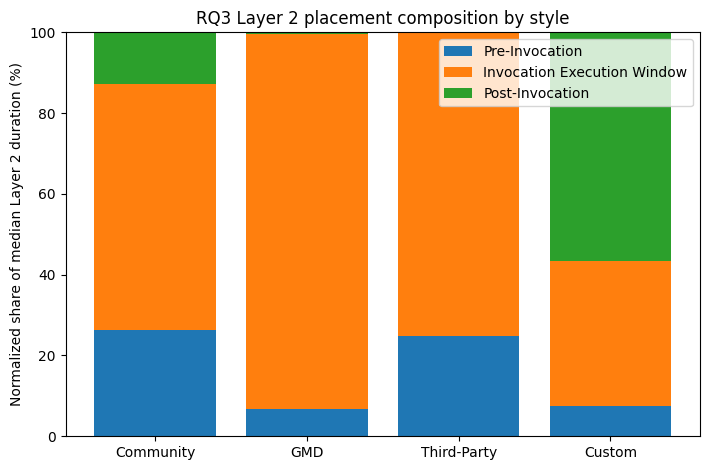

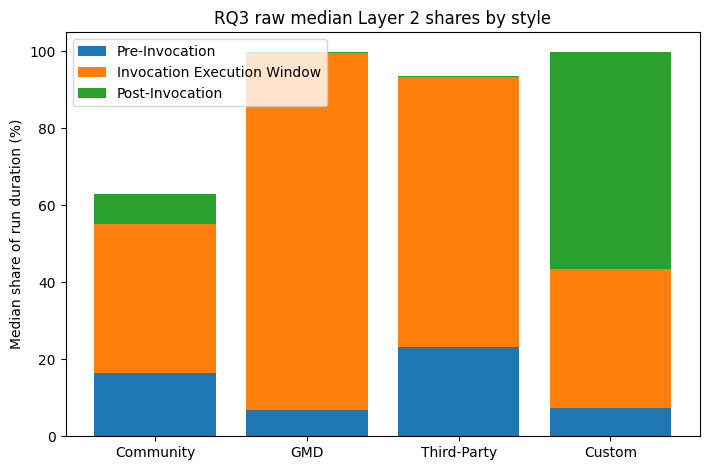


=== RQ3: Raw median Layer 2 shares ===
             pre_share  exec_share  post_share  sum_of_median_shares
style                                                               
Community        0.165       0.385       0.080                 0.630
GMD              0.068       0.927       0.004                 0.999
Third-Party      0.233       0.701       0.003                 0.936
Custom           0.074       0.359       0.564                 0.998

=== RQ3: 100-normalized display shares ===
             pre_share  exec_share  post_share
style                                         
Community         26.2        61.1        12.7
GMD                6.8        92.8         0.4
Third-Party       24.9        74.9         0.3
Custom             7.4        36.0        56.5

=== RQ3: Median seconds ===
             study_pre_invocation_selected_stage3_seconds  study_invocation_execution_window_selected_stage3_seconds  study_post_invocation_selected_stage3_seconds  study_run_duration_seconds

In [26]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Paths
# ============================================================
BASE_DIR = Path(r"C:\Android Mobile App\ICST2026_Ext")
OUT_DIR = Path(r"C:\Android Mobile App\ICST2026_Ext\3.0-Observations\RQ3")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MAIN_DATASET_CANDIDATES = [
    BASE_DIR / "MainDataset.csv",
    BASE_DIR / "data" / "processed" / "MainDataset.csv",
    BASE_DIR / "data" / "processed" / "main_dataset.csv",
    BASE_DIR / "outputs" / "MainDataset.csv",
]

STYLE_ORDER = ["Community", "GMD", "Third-Party", "Custom"]

# ============================================================
# Helpers
# ============================================================
def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError(
        "Could not find MainDataset.csv. Tried:\n" + "\n".join(str(p) for p in paths)
    )

def find_first_existing(df_cols, candidates, label):
    for c in candidates:
        if c in df_cols:
            return c
    raise ValueError(f"Could not find column for '{label}'. Tried: {candidates}")

def to_numeric(s):
    return pd.to_numeric(s, errors="coerce")

def nz_div(a, b):
    return np.where((b.notna()) & (b != 0), a / b, np.nan)

def med(series):
    s = to_numeric(series).dropna()
    return np.nan if s.empty else float(s.median())

def q95(series):
    s = to_numeric(series).dropna()
    return np.nan if s.empty else float(np.percentile(s, 95))

def safe_share(num, den):
    num = to_numeric(num)
    den = to_numeric(den)
    out = num / den
    out[(den.isna()) | (den == 0)] = np.nan
    return out

def dataframe_to_markdown(df: pd.DataFrame) -> str:
    cols = list(df.columns)
    header = "| " + " | ".join(["index"] + cols) + " |"
    sep = "|" + "---|" * (len(cols) + 1)
    rows = []
    for idx, row in df.iterrows():
        vals = [str(row[c]) for c in cols]
        rows.append("| " + " | ".join([str(idx)] + vals) + " |")
    return "\n".join([header, sep] + rows)

# ============================================================
# Load dataset
# ============================================================
main_dataset_path = first_existing(MAIN_DATASET_CANDIDATES)
df = pd.read_csv(main_dataset_path)

print(f"Loaded dataset: {main_dataset_path}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

# ============================================================
# Resolve columns
# ============================================================
style_col = find_first_existing(
    df.columns,
    ["style", "study_style"],
    "style"
)

instr_exec_col = find_first_existing(
    df.columns,
    ["controller_instru_job_count_gt0", "controller_instrumentation_executed"],
    "instrumentation executed flag"
)

first_attempt_col = find_first_existing(
    df.columns,
    ["controller_attempt_eq_1", "controller_first_attempt"],
    "first attempt flag"
)

run_conclusion_col = find_first_existing(
    df.columns,
    ["run_conclusion", "conclusion"],
    "run conclusion"
)

run_duration_col = find_first_existing(
    df.columns,
    ["study_run_duration_seconds", "run_duration_seconds"],
    "run duration"
)

pre_inv_col = find_first_existing(
    df.columns,
    [
        "study_pre_invocation_selected_stage3_seconds",
        "study_pre_invocation_seconds",
        "pre_invocation_seconds",
    ],
    "pre-invocation"
)

exec_window_col = find_first_existing(
    df.columns,
    [
        "study_invocation_execution_window_selected_stage3_seconds",
        "study_invocation_execution_window_seconds",
        "invocation_execution_window_seconds",
    ],
    "invocation execution window"
)

post_inv_col = find_first_existing(
    df.columns,
    [
        "study_post_invocation_selected_stage3_seconds",
        "study_post_invocation_seconds",
        "post_invocation_seconds",
    ],
    "post-invocation"
)

print("\nResolved columns:")
for name, col in [
    ("style", style_col),
    ("instrumentation executed", instr_exec_col),
    ("first attempt", first_attempt_col),
    ("run conclusion", run_conclusion_col),
    ("run duration", run_duration_col),
    ("pre-invocation", pre_inv_col),
    ("exec-window", exec_window_col),
    ("post-invocation", post_inv_col),
]:
    print(f" - {name:24s}: {col}")

# Optional grouping columns if present
activity_col = next((c for c in [
    "selected_stage3_step_activity_group",
    "step_activity_group",
    "study_step_activity_group"
] if c in df.columns), None)

exec_role_col = next((c for c in [
    "selected_stage3_execution_role",
    "execution_role",
    "study_execution_role"
] if c in df.columns), None)

phase_col = next((c for c in [
    "selected_stage3_overhead_phase",
    "overhead_phase",
    "study_overhead_phase"
] if c in df.columns), None)

# ============================================================
# Base regime for RQ3
# instrumentation-executed + first-attempt + usable verdict
# ============================================================
base_mask = (
    df[style_col].isin(STYLE_ORDER)
    & df[instr_exec_col].astype(bool)
    & df[first_attempt_col].astype(bool)
    & df[run_conclusion_col].isin(["success", "failure"])
)

base_df = df.loc[base_mask].copy()

# Step-observable Layer 2 subset
for c in [run_duration_col, pre_inv_col, exec_window_col, post_inv_col]:
    base_df[c] = to_numeric(base_df[c])

l2_df = base_df[
    base_df[run_duration_col].notna()
    & base_df[pre_inv_col].notna()
    & base_df[exec_window_col].notna()
    & base_df[post_inv_col].notna()
].copy()

if l2_df.empty:
    raise ValueError("No step-observable Base rows found for RQ3.")

print(f"\nBase rows: {len(base_df):,}")
print(f"Layer 2 step-observable Base rows: {len(l2_df):,}")

# ============================================================
# Build Layer 2 shares
# ============================================================
l2_df["pre_share"] = safe_share(l2_df[pre_inv_col], l2_df[run_duration_col])
l2_df["exec_share"] = safe_share(l2_df[exec_window_col], l2_df[run_duration_col])
l2_df["post_share"] = safe_share(l2_df[post_inv_col], l2_df[run_duration_col])

share_summary = (
    l2_df.groupby(style_col)[["pre_share", "exec_share", "post_share"]]
    .median()
    .reindex(STYLE_ORDER)
)

share_summary["sum_of_median_shares"] = (
    share_summary["pre_share"] + share_summary["exec_share"] + share_summary["post_share"]
)

# normalized-to-100 display version
share_100 = share_summary[["pre_share", "exec_share", "post_share"]].copy()
share_100 = share_100.div(share_100.sum(axis=1), axis=0) * 100

# raw medians in seconds too
seconds_summary = (
    l2_df.groupby(style_col)[[pre_inv_col, exec_window_col, post_inv_col, run_duration_col]]
    .median()
    .reindex(STYLE_ORDER)
)

# ============================================================
# Observation-oriented diagnostic labels
# ============================================================
def dominant_region(row):
    vals = {
        "Pre-Invocation": row["pre_share"],
        "Invocation Execution Window": row["exec_share"],
        "Post-Invocation": row["post_share"],
    }
    return max(vals, key=vals.get)

diag_rows = []
for style in STYLE_ORDER:
    row = share_summary.loc[style]
    pre_s = row["pre_share"]
    exec_s = row["exec_share"]
    post_s = row["post_share"]
    dom = dominant_region(row)

    # profile-facing label aligned with current RQ3 wording
    if style == "GMD":
        profile = "Execution-centric"
        first_target = "Optimize execution path"
    elif style == "Third-Party":
        profile = "Heavy entry + heavy execution"
        first_target = "Reduce entry/provisioning delay, then execution cost"
    elif style == "Community":
        profile = "Distributed overhead"
        first_target = "Balance setup, execution, and residual reporting/finalization"
    else:
        profile = "Tail-heavy mixed case"
        first_target = "Reduce residual completion-tail work cautiously"

    diag_rows.append({
        "style": style,
        "dominant_region": dom,
        "median_pre_share": pre_s,
        "median_exec_share": exec_s,
        "median_post_share": post_s,
        "profile_reading": profile,
        "first_optimization_target": first_target,
    })

diag_df = pd.DataFrame(diag_rows).set_index("style").reindex(STYLE_ORDER)

# ============================================================
# Optional step-label diagnostics if columns exist
# This part is intentionally conservative: it summarizes visible labels
# but does not force them if your dataset version does not contain them.
# ============================================================
activity_summary = None
exec_role_summary = None
phase_summary = None

if activity_col:
    activity_summary = (
        l2_df.groupby([style_col, activity_col]).size()
        .rename("n")
        .reset_index()
        .pivot(index=style_col, columns=activity_col, values="n")
        .fillna(0)
        .reindex(STYLE_ORDER)
    )

if exec_role_col:
    exec_role_summary = (
        l2_df.groupby([style_col, exec_role_col]).size()
        .rename("n")
        .reset_index()
        .pivot(index=style_col, columns=exec_role_col, values="n")
        .fillna(0)
        .reindex(STYLE_ORDER)
    )

if phase_col:
    phase_summary = (
        l2_df.groupby([style_col, phase_col]).size()
        .rename("n")
        .reset_index()
        .pivot(index=style_col, columns=phase_col, values="n")
        .fillna(0)
        .reindex(STYLE_ORDER)
    )

# ============================================================
# Save tabular outputs
# ============================================================
share_summary_out = share_summary.copy()
for col in share_summary_out.columns:
    share_summary_out[col] = share_summary_out[col].map(lambda x: round(float(x), 3) if pd.notna(x) else "")

share_100_out = share_100.copy()
for col in share_100_out.columns:
    share_100_out[col] = share_100_out[col].map(lambda x: round(float(x), 1) if pd.notna(x) else "")

seconds_summary_out = seconds_summary.copy()
for col in seconds_summary_out.columns:
    seconds_summary_out[col] = seconds_summary_out[col].map(lambda x: round(float(x), 1) if pd.notna(x) else "")

diag_out = diag_df.copy()
for c in ["median_pre_share", "median_exec_share", "median_post_share"]:
    diag_out[c] = diag_out[c].map(lambda x: round(float(x), 3) if pd.notna(x) else "")

# CSV / XLSX / MD
share_summary_out.to_csv(OUT_DIR / "rq3_layer2_share_medians_raw.csv", encoding="utf-8")
share_100_out.to_csv(OUT_DIR / "rq3_layer2_share_medians_100.csv", encoding="utf-8")
seconds_summary_out.to_csv(OUT_DIR / "rq3_layer2_seconds_medians.csv", encoding="utf-8")
diag_out.to_csv(OUT_DIR / "rq3_observation_diagnostics.csv", encoding="utf-8")

with pd.ExcelWriter(OUT_DIR / "rq3_observation_outputs.xlsx", engine="openpyxl") as writer:
    share_summary_out.to_excel(writer, sheet_name="raw_shares")
    share_100_out.to_excel(writer, sheet_name="shares_100")
    seconds_summary_out.to_excel(writer, sheet_name="median_seconds")
    diag_out.to_excel(writer, sheet_name="diagnostics")
    if activity_summary is not None:
        activity_summary.to_excel(writer, sheet_name="activity_groups")
    if exec_role_summary is not None:
        exec_role_summary.to_excel(writer, sheet_name="execution_roles")
    if phase_summary is not None:
        phase_summary.to_excel(writer, sheet_name="overhead_phases")

(OUT_DIR / "rq3_layer2_share_medians_raw.md").write_text(
    dataframe_to_markdown(share_summary_out), encoding="utf-8"
)
(OUT_DIR / "rq3_layer2_share_medians_100.md").write_text(
    dataframe_to_markdown(share_100_out), encoding="utf-8"
)
(OUT_DIR / "rq3_layer2_seconds_medians.md").write_text(
    dataframe_to_markdown(seconds_summary_out), encoding="utf-8"
)
(OUT_DIR / "rq3_observation_diagnostics.md").write_text(
    dataframe_to_markdown(diag_out), encoding="utf-8"
)

# ============================================================
# Build paper-facing compact diagnostic table (similar to Table V support)
# ============================================================
paper_rows = []
for style in STYLE_ORDER:
    if style == "Community":
        paper_rows.append({
            "Style": style,
            "Main Layer 2 bottleneck": "Mixed, with meaningful execution plus a non-trivial residual tail",
            "Profile-facing interpretation / first target":
                "Distributed overhead profile. Optimize across more than one source; execution-path efficiency plus residual reporting/finalization."
        })
    elif style == "GMD":
        paper_rows.append({
            "Style": style,
            "Main Layer 2 bottleneck": "Invocation Execution Window",
            "Profile-facing interpretation / first target":
                "Clearest execution-centric profile. First target is the core execution path itself."
        })
    elif style == "Third-Party":
        paper_rows.append({
            "Style": style,
            "Main Layer 2 bottleneck": "Pre-Invocation plus Invocation Execution Window",
            "Profile-facing interpretation / first target":
                "Heavy-entry plus heavy-execution profile. First targets are entry/orchestration delay and then execution-path cost."
        })
    else:
        paper_rows.append({
            "Style": style,
            "Main Layer 2 bottleneck": "Large residual completion tail in Layer 2",
            "Profile-facing interpretation / first target":
                "Tail-heavy mixed case. First target remains residual completion-tail reduction, interpreted cautiously."
        })

paper_table = pd.DataFrame(paper_rows).set_index("Style")
paper_table.to_csv(OUT_DIR / "rq3_paper_facing_diagnostic_table.csv", encoding="utf-8")
paper_table.to_excel(OUT_DIR / "rq3_paper_facing_diagnostic_table.xlsx")
(OUT_DIR / "rq3_paper_facing_diagnostic_table.md").write_text(
    dataframe_to_markdown(paper_table), encoding="utf-8"
)

# ============================================================
# Plot 1: normalized 100% stacked bar chart
# ============================================================
plot_df = share_100.reindex(STYLE_ORDER)

fig, ax = plt.subplots(figsize=(7.2, 4.8))

x = np.arange(len(plot_df))
pre_vals = plot_df["pre_share"].values
exec_vals = plot_df["exec_share"].values
post_vals = plot_df["post_share"].values

ax.bar(x, pre_vals, label="Pre-Invocation")
ax.bar(x, exec_vals, bottom=pre_vals, label="Invocation Execution Window")
ax.bar(x, post_vals, bottom=pre_vals + exec_vals, label="Post-Invocation")

ax.set_xticks(x)
ax.set_xticklabels(STYLE_ORDER)
ax.set_ylabel("Normalized share of median Layer 2 duration (%)")
ax.set_ylim(0, 100)
ax.legend()
ax.set_title("RQ3 Layer 2 placement composition by style")

plt.tight_layout()
png_path = OUT_DIR / "rq3_stacked_barchart_layer2_overhead_shares_100.png"
pdf_path = OUT_DIR / "rq3_stacked_barchart_layer2_overhead_shares_100.pdf"
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

# ============================================================
# Plot 2: raw median shares (not normalized to 100) for diagnostics
# ============================================================
raw_plot = share_summary[["pre_share", "exec_share", "post_share"]].reindex(STYLE_ORDER) * 100

fig, ax = plt.subplots(figsize=(7.2, 4.8))
x = np.arange(len(raw_plot))
pre_vals = raw_plot["pre_share"].values
exec_vals = raw_plot["exec_share"].values
post_vals = raw_plot["post_share"].values

ax.bar(x, pre_vals, label="Pre-Invocation")
ax.bar(x, exec_vals, bottom=pre_vals, label="Invocation Execution Window")
ax.bar(x, post_vals, bottom=pre_vals + exec_vals, label="Post-Invocation")

ax.set_xticks(x)
ax.set_xticklabels(STYLE_ORDER)
ax.set_ylabel("Median share of run duration (%)")
ax.legend()
ax.set_title("RQ3 raw median Layer 2 shares by style")

plt.tight_layout()
png_path2 = OUT_DIR / "rq3_stacked_barchart_layer2_overhead_shares_raw.png"
pdf_path2 = OUT_DIR / "rq3_stacked_barchart_layer2_overhead_shares_raw.pdf"
plt.savefig(png_path2, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path2, bbox_inches="tight")
plt.show()

# ============================================================
# Print key outputs in notebook / console
# ============================================================
print("\n=== RQ3: Raw median Layer 2 shares ===")
print(share_summary_out.to_string())

print("\n=== RQ3: 100-normalized display shares ===")
print(share_100_out.to_string())

print("\n=== RQ3: Median seconds ===")
print(seconds_summary_out.to_string())

print("\n=== RQ3: Observation diagnostics ===")
print(diag_out.to_string())

print("\nSaved outputs to:")
for p in [
    OUT_DIR / "rq3_layer2_share_medians_raw.csv",
    OUT_DIR / "rq3_layer2_share_medians_100.csv",
    OUT_DIR / "rq3_layer2_seconds_medians.csv",
    OUT_DIR / "rq3_observation_diagnostics.csv",
    OUT_DIR / "rq3_observation_outputs.xlsx",
    OUT_DIR / "rq3_paper_facing_diagnostic_table.csv",
    OUT_DIR / "rq3_stacked_barchart_layer2_overhead_shares_100.png",
    OUT_DIR / "rq3_stacked_barchart_layer2_overhead_shares_100.pdf",
    OUT_DIR / "rq3_stacked_barchart_layer2_overhead_shares_raw.png",
    OUT_DIR / "rq3_stacked_barchart_layer2_overhead_shares_raw.pdf",
]:
    print(" -", p)

In [5]:
# ============================================================
# RQ4 Reproducibility Script
# Deployment context and run-level verdict usability
#
# RQ4 regime:
#   instrumentation-executed + first attempt
#   (all outcomes retained; no usable-verdict filter)
#
# Reads:
#   D:\0.1-Data_Mar18_V20.0\MainDataset.csv
#
# Writes:
#   D:\0.1-Data_Mar18_V20.0\RQ4\
#       - rq4_first_attempt_counts.csv
#       - rq4_usable_verdict_by_style.csv
#       - rq4_success_among_usable_by_style.csv
#       - rq4_event_by_style_counts.csv
#       - rq4_overall_tests.csv
#       - rq4_pairwise_tests.csv
#       - rq4_within_style_event_conditioned_success.csv
#       - rq4_summary.txt
#
# Notes:
# - usable verdict = run_conclusion in {"success", "failure"}
# - success rate is computed among usable verdicts only
# - event column assumed to be: event
# - robust to degenerate 2x2 event tables
# ============================================================

from __future__ import annotations

import itertools
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact


# -----------------------------
# Paths
# -----------------------------
INPUT_DIR = Path(r"D:\0.1-Data_Mar18_V20.0")
INPUT_CSV = INPUT_DIR / "MainDataset.csv"
OUTPUT_DIR = INPUT_DIR / "RQ4"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# -----------------------------
# Study setup
# -----------------------------
STYLE_ORDER = ["Community", "Custom", "GMD", "Third-Party"]
USABLE_VERDICTS = {"success", "failure"}
SUCCESS = "success"
FAILURE = "failure"

# Adjust this only if your dataset uses a different event column name.
EVENT_COL = "event"
OTHER_EVENT_LABEL = "other"

MAIN_EVENTS = ["push", "pull_request", "schedule", "workflow_dispatch"]


# -----------------------------
# Helper functions
# -----------------------------
def cramers_v_from_table(table: np.ndarray) -> float:
    """
    Cramer's V from contingency table.
    Returns NaN for degenerate tables.
    """
    table = np.asarray(table, dtype=float)

    if table.size == 0:
        return np.nan
    if table.ndim != 2:
        return np.nan
    if table.sum() == 0:
        return np.nan

    # Degenerate table: any row/col sum is zero
    if np.any(table.sum(axis=0) == 0) or np.any(table.sum(axis=1) == 0):
        return np.nan

    try:
        chi2, _, _, _ = chi2_contingency(table)
    except ValueError:
        return np.nan

    n = table.sum()
    r, c = table.shape
    denom = min(r - 1, c - 1)
    if denom <= 0:
        return np.nan

    return np.sqrt(chi2 / (n * denom))


def choose_test_2x2(table_2x2: np.ndarray) -> Tuple[str, float]:
    """
    Use Fisher for sparse/degenerate 2x2 tables, chi-square otherwise.
    """
    table_2x2 = np.asarray(table_2x2)

    if table_2x2.shape != (2, 2):
        raise ValueError("choose_test_2x2 expects a 2x2 table")

    # Degenerate row/column
    if np.any(table_2x2.sum(axis=0) == 0) or np.any(table_2x2.sum(axis=1) == 0):
        try:
            _, p = fisher_exact(table_2x2)
            return "fisher", p
        except Exception:
            return "degenerate", np.nan

    # Sparse table
    if (table_2x2 < 5).any():
        try:
            _, p = fisher_exact(table_2x2)
            return "fisher", p
        except Exception:
            return "degenerate", np.nan

    try:
        chi2, p, _, _ = chi2_contingency(table_2x2)
        return "chi2", p
    except ValueError:
        try:
            _, p = fisher_exact(table_2x2)
            return "fisher", p
        except Exception:
            return "degenerate", np.nan


def fmt_p(p: float) -> str:
    if pd.isna(p):
        return "NA"
    if p < 1e-4:
        return f"{p:.2e}"
    return f"{p:.4f}"


def wilson_ci(k: int, n: int, z: float = 1.96) -> Tuple[float, float]:
    """
    Wilson score interval for a proportion.
    """
    if n == 0:
        return (np.nan, np.nan)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    half = z * np.sqrt((phat * (1 - phat) + z**2 / (4 * n)) / n) / denom
    return (center - half, center + half)


def simplify_event(x: object) -> str:
    """
    Keep common event names readable, collapse blanks/rare values to 'other'.
    """
    if pd.isna(x):
        return OTHER_EVENT_LABEL
    s = str(x).strip()
    if not s:
        return OTHER_EVENT_LABEL

    keep = {
        "push",
        "pull_request",
        "schedule",
        "workflow_dispatch",
        "pull_request_target",
        "release",
    }
    return s if s in keep else OTHER_EVENT_LABEL


# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(INPUT_CSV)

if EVENT_COL not in df.columns:
    raise KeyError(
        f"Expected event column '{EVENT_COL}' not found in MainDataset.csv. "
        f"Available columns include: {list(df.columns[:20])} ..."
    )

# -----------------------------
# Define RQ4 regime
# instrumentation-executed + first attempt
# all conclusions retained
# -----------------------------
rq4 = df[
    (df["controller_instru_job_count_gt0"] == True)
    & (df["controller_attempt_eq_1"] == True)
].copy()

rq4 = rq4[rq4["style"].isin(STYLE_ORDER)].copy()

rq4["event_clean"] = rq4[EVENT_COL].apply(simplify_event)
rq4["is_usable_verdict"] = rq4["run_conclusion"].isin(USABLE_VERDICTS)
rq4["is_success"] = rq4["run_conclusion"].eq(SUCCESS)
rq4["is_failure"] = rq4["run_conclusion"].eq(FAILURE)


# -----------------------------
# 1) First-attempt counts by style
# -----------------------------
first_attempt_counts = (
    rq4.groupby("style", dropna=False)
    .size()
    .reindex(STYLE_ORDER, fill_value=0)
    .reset_index(name="n_first_attempt")
)
first_attempt_counts.to_csv(OUTPUT_DIR / "rq4_first_attempt_counts.csv", index=False)


# -----------------------------
# 2) Usable verdict by style
# -----------------------------
usable_rows = []
for style in STYLE_ORDER:
    sub = rq4[rq4["style"] == style]
    n_total = len(sub)
    n_success = int(sub["is_success"].sum())
    n_failure = int(sub["is_failure"].sum())
    n_usable = int(sub["is_usable_verdict"].sum())
    n_nonusable = n_total - n_usable
    n_cancelled = int((sub["run_conclusion"] == "cancelled").sum())
    n_missing = int(sub["run_conclusion"].isna().sum())
    rate = n_usable / n_total if n_total else np.nan
    lo, hi = wilson_ci(n_usable, n_total)

    usable_rows.append(
        {
            "style": style,
            "n_total": n_total,
            "n_success": n_success,
            "n_failure": n_failure,
            "n_usable": n_usable,
            "n_nonusable": n_nonusable,
            "n_cancelled": n_cancelled,
            "n_missing_conclusion": n_missing,
            "usable_verdict_rate": rate,
            "usable_verdict_rate_ci_low": lo,
            "usable_verdict_rate_ci_high": hi,
        }
    )

usable_df = pd.DataFrame(usable_rows)
usable_df.to_csv(OUTPUT_DIR / "rq4_usable_verdict_by_style.csv", index=False)


# -----------------------------
# 3) Success among usable verdicts
# -----------------------------
success_rows = []
usable_only = rq4[rq4["is_usable_verdict"]].copy()

for style in STYLE_ORDER:
    sub = usable_only[usable_only["style"] == style]
    n_usable = len(sub)
    n_success = int(sub["is_success"].sum())
    n_failure = int(sub["is_failure"].sum())
    success_rate = n_success / n_usable if n_usable else np.nan
    lo, hi = wilson_ci(n_success, n_usable)

    success_rows.append(
        {
            "style": style,
            "n_usable": n_usable,
            "n_success": n_success,
            "n_failure": n_failure,
            "success_rate_among_usable": success_rate,
            "success_rate_ci_low": lo,
            "success_rate_ci_high": hi,
        }
    )

success_df = pd.DataFrame(success_rows)
success_df.to_csv(OUTPUT_DIR / "rq4_success_among_usable_by_style.csv", index=False)


# -----------------------------
# 4) Event distribution by style
# -----------------------------
event_counts = pd.crosstab(
    rq4["style"],
    rq4["event_clean"],
    dropna=False,
).reindex(index=STYLE_ORDER, fill_value=0)

event_counts.to_csv(OUTPUT_DIR / "rq4_event_by_style_counts.csv")


# -----------------------------
# 5) Overall tests
# -----------------------------
overall_test_rows = []

# 5a) style x usable verdict
table_style_usable = pd.crosstab(
    rq4["style"],
    rq4["is_usable_verdict"],
    dropna=False,
).reindex(index=STYLE_ORDER, columns=[False, True], fill_value=0)

chi2, p, _, _ = chi2_contingency(table_style_usable.values)
overall_test_rows.append(
    {
        "test_name": "style_x_usable_verdict",
        "table_shape": str(table_style_usable.shape),
        "n_total": int(table_style_usable.values.sum()),
        "chi2": chi2,
        "p_value": p,
        "effect_size": cramers_v_from_table(table_style_usable.values),
        "effect_name": "cramers_v",
    }
)

# 5b) style x success/failure among usable only
table_style_success = pd.crosstab(
    usable_only["style"],
    usable_only["run_conclusion"],
    dropna=False,
).reindex(index=STYLE_ORDER, columns=[SUCCESS, FAILURE], fill_value=0)

chi2, p, _, _ = chi2_contingency(table_style_success.values)
overall_test_rows.append(
    {
        "test_name": "style_x_success_failure_among_usable",
        "table_shape": str(table_style_success.shape),
        "n_total": int(table_style_success.values.sum()),
        "chi2": chi2,
        "p_value": p,
        "effect_size": cramers_v_from_table(table_style_success.values),
        "effect_name": "cramers_v",
    }
)

# 5c) style x event
table_style_event = pd.crosstab(
    rq4["style"],
    rq4["event_clean"],
    dropna=False,
).reindex(index=STYLE_ORDER, fill_value=0)

chi2, p, _, _ = chi2_contingency(table_style_event.values)
overall_test_rows.append(
    {
        "test_name": "style_x_event",
        "table_shape": str(table_style_event.shape),
        "n_total": int(table_style_event.values.sum()),
        "chi2": chi2,
        "p_value": p,
        "effect_size": cramers_v_from_table(table_style_event.values),
        "effect_name": "cramers_v",
    }
)

overall_tests_df = pd.DataFrame(overall_test_rows)
overall_tests_df.to_csv(OUTPUT_DIR / "rq4_overall_tests.csv", index=False)


# -----------------------------
# 6) Pairwise tests
# -----------------------------
pairwise_rows = []

# 6a) Pairwise style comparisons on usable verdict rate
for s1, s2 in itertools.combinations(STYLE_ORDER, 2):
    sub = rq4[rq4["style"].isin([s1, s2])].copy()
    table = pd.crosstab(sub["style"], sub["is_usable_verdict"]).reindex(
        index=[s1, s2], columns=[False, True], fill_value=0
    )

    if table.values.sum() == 0:
        continue

    test_name, p = choose_test_2x2(table.values)
    pairwise_rows.append(
        {
            "comparison_family": "pairwise_style_usable_verdict",
            "group_1": s1,
            "group_2": s2,
            "test_used": test_name,
            "p_value": p,
            "effect_size": cramers_v_from_table(table.values),
            "effect_name": "cramers_v",
            "table_json": str(table.to_dict()),
        }
    )

# 6b) Pairwise style comparisons on success/failure among usable only
for s1, s2 in itertools.combinations(STYLE_ORDER, 2):
    sub = usable_only[usable_only["style"].isin([s1, s2])].copy()
    table = pd.crosstab(sub["style"], sub["run_conclusion"]).reindex(
        index=[s1, s2], columns=[SUCCESS, FAILURE], fill_value=0
    )

    if table.values.sum() == 0:
        continue

    test_name, p = choose_test_2x2(table.values)
    pairwise_rows.append(
        {
            "comparison_family": "pairwise_style_success_failure_among_usable",
            "group_1": s1,
            "group_2": s2,
            "test_used": test_name,
            "p_value": p,
            "effect_size": cramers_v_from_table(table.values),
            "effect_name": "cramers_v",
            "table_json": str(table.to_dict()),
        }
    )

# 6c) Pairwise style comparisons on selected event presence
for event_name in MAIN_EVENTS:
    indicator_col = f"is_event_{event_name}"
    rq4[indicator_col] = rq4["event_clean"].eq(event_name)

    for s1, s2 in itertools.combinations(STYLE_ORDER, 2):
        sub = rq4[rq4["style"].isin([s1, s2])].copy()
        table = pd.crosstab(sub["style"], sub[indicator_col]).reindex(
            index=[s1, s2], columns=[False, True], fill_value=0
        )

        if table.values.sum() == 0 or table.shape != (2, 2):
            continue

        test_name, p = choose_test_2x2(table.values)
        pairwise_rows.append(
            {
                "comparison_family": f"pairwise_style_event_{event_name}",
                "group_1": s1,
                "group_2": s2,
                "test_used": test_name,
                "p_value": p,
                "effect_size": cramers_v_from_table(table.values),
                "effect_name": "cramers_v",
                "table_json": str(table.to_dict()),
            }
        )

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df.to_csv(OUTPUT_DIR / "rq4_pairwise_tests.csv", index=False)


# -----------------------------
# 7) Within-style event-conditioned success-rate tests
# Among usable verdicts only
# -----------------------------
within_style_rows = []

for style in STYLE_ORDER:
    sub = usable_only[usable_only["style"] == style].copy()
    if sub.empty:
        continue

    event_counts_style = sub["event_clean"].value_counts()
    style_events = [e for e, n in event_counts_style.items() if n > 0]

    for e1, e2 in itertools.combinations(style_events, 2):
        sub2 = sub[sub["event_clean"].isin([e1, e2])].copy()
        table = pd.crosstab(sub2["event_clean"], sub2["run_conclusion"]).reindex(
            index=[e1, e2], columns=[SUCCESS, FAILURE], fill_value=0
        )

        if table.shape != (2, 2) or table.values.sum() == 0:
            continue

        test_name, p = choose_test_2x2(table.values)

        n1 = int(table.loc[e1].sum())
        n2 = int(table.loc[e2].sum())
        sr1 = table.loc[e1, SUCCESS] / n1 if n1 else np.nan
        sr2 = table.loc[e2, SUCCESS] / n2 if n2 else np.nan

        within_style_rows.append(
            {
                "style": style,
                "event_1": e1,
                "event_2": e2,
                "n_event_1": n1,
                "n_event_2": n2,
                "success_rate_event_1": sr1,
                "success_rate_event_2": sr2,
                "test_used": test_name,
                "p_value": p,
                "effect_size": cramers_v_from_table(table.values),
                "effect_name": "cramers_v",
                "table_json": str(table.to_dict()),
            }
        )

within_style_df = pd.DataFrame(within_style_rows)
within_style_df.to_csv(
    OUTPUT_DIR / "rq4_within_style_event_conditioned_success.csv", index=False
)


# -----------------------------
# 8) Summary text
# -----------------------------
summary_lines: List[str] = []
summary_lines.append("RQ4 reproducibility summary")
summary_lines.append("=" * 72)
summary_lines.append(f"Input file: {INPUT_CSV}")
summary_lines.append(f"RQ4 regime size (first-attempt instrumentation-executed): {len(rq4):,}")
summary_lines.append("")

summary_lines.append("First-attempt counts by style:")
for _, row in first_attempt_counts.iterrows():
    summary_lines.append(f"  - {row['style']}: {row['n_first_attempt']:,}")
summary_lines.append("")

summary_lines.append("Usable verdict by style:")
for _, row in usable_df.iterrows():
    summary_lines.append(
        f"  - {row['style']}: usable={row['n_usable']}/{row['n_total']} "
        f"({row['usable_verdict_rate']*100:.1f}%), "
        f"success={row['n_success']}, failure={row['n_failure']}, "
        f"cancelled={row['n_cancelled']}, missing={row['n_missing_conclusion']}"
    )
summary_lines.append("")

summary_lines.append("Success rate among usable verdicts:")
for _, row in success_df.iterrows():
    summary_lines.append(
        f"  - {row['style']}: success={row['n_success']}/{row['n_usable']} "
        f"({row['success_rate_among_usable']*100:.1f}%)"
    )
summary_lines.append("")

summary_lines.append("Overall tests:")
for _, row in overall_tests_df.iterrows():
    summary_lines.append(
        f"  - {row['test_name']}: chi2={row['chi2']:.3f}, "
        f"p={fmt_p(row['p_value'])}, "
        f"Cramer's V={row['effect_size']:.4f}"
    )
summary_lines.append("")

summary_lines.append("Event distribution by style:")
event_prop = event_counts.div(event_counts.sum(axis=1), axis=0).fillna(0)
for style in STYLE_ORDER:
    if style not in event_prop.index:
        continue
    summary_lines.append(f"  {style}:")
    for ev, prop in event_prop.loc[style].sort_values(ascending=False).items():
        if prop > 0:
            summary_lines.append(f"    - {ev}: {prop*100:.1f}%")
summary_lines.append("")

summary_lines.append("Selected within-style event-conditioned success-rate tests:")
if within_style_df.empty:
    summary_lines.append("  - No within-style event-conditioned contrasts available.")
else:
    for _, row in within_style_df.sort_values(["style", "p_value"]).head(20).iterrows():
        sr1 = row["success_rate_event_1"] * 100 if pd.notna(row["success_rate_event_1"]) else np.nan
        sr2 = row["success_rate_event_2"] * 100 if pd.notna(row["success_rate_event_2"]) else np.nan
        summary_lines.append(
            f"  - {row['style']}: {row['event_1']} vs {row['event_2']} "
            f"(success rates {sr1:.1f}% vs {sr2:.1f}%), "
            f"{row['test_used']} p={fmt_p(row['p_value'])}, "
            f"Cramer's V={row['effect_size']:.4f}"
        )

summary_text = "\n".join(summary_lines)
print(summary_text)

with open(OUTPUT_DIR / "rq4_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("\nSaved outputs to:", OUTPUT_DIR)

RQ4 reproducibility summary
Input file: D:\0.1-Data_Mar18_V20.0\MainDataset.csv
RQ4 regime size (first-attempt instrumentation-executed): 8,666

First-attempt counts by style:
  - Community: 7,826
  - Custom: 39
  - GMD: 265
  - Third-Party: 536

Usable verdict by style:
  - Community: usable=6980/7826 (89.2%), success=5523, failure=1457, cancelled=841, missing=5
  - Custom: usable=34/39 (87.2%), success=8, failure=26, cancelled=5, missing=0
  - GMD: usable=263/265 (99.2%), success=258, failure=5, cancelled=2, missing=0
  - Third-Party: usable=526/536 (98.1%), success=87, failure=439, cancelled=10, missing=0

Success rate among usable verdicts:
  - Community: success=5523/6980 (79.1%)
  - Custom: success=8/34 (23.5%)
  - GMD: success=258/263 (98.1%)
  - Third-Party: success=87/526 (16.5%)

Overall tests:
  - style_x_usable_verdict: chi2=70.871, p=2.78e-15, Cramer's V=0.0904
  - style_x_success_failure_among_usable: chi2=1154.040, p=6.87e-250, Cramer's V=0.3846
  - style_x_event: chi2=4

In [ ]:
#robustness check

In [1]:
# -*- coding: utf-8 -*-
"""
Compute Table XI:
Tier-2 paired coarsened-family statistical support
for the selected key observations.

Reads:
    C:\Android Mobile App\ICST2026_Ext\MainDataset.csv

Writes:
    C:\Android Mobile App\ICST2026_Ext\2.0-RQ_Support_Robustness_Check\
        - table_xi_tier2_stats.csv
        - table_xi_tier2_stats.tex
        - table_xi_tier2_stats_readme.txt

Notes
-----
- RQ1–RQ3 robustness checks are run under the Base timing regime.
- RQ4 robustness checks are run under the first-attempt outcome regime.
- Obs. 4.2 is additionally conditioned on usable verdicts (success/failure).
- Tier 2 families are built from eligible exact signatures using:
    * same runner OS bucket
    * adjacent-or-equal executed job-count bucket
    * adjacent-or-equal executed step-count bucket
"""

from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple, Optional
import math
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu, chi2_contingency


# ============================================================
# CONFIG
# ============================================================
BASE_DIR = Path(r"C:\Android Mobile App\ICST2026_Ext")
IN_MAIN = BASE_DIR / "MainDataset.csv"
OUT_DIR = BASE_DIR / "2.0-RQ_Support_Robustness_Check"

OUT_CSV = OUT_DIR / "table_xi_tier2_stats.csv"
OUT_TEX = OUT_DIR / "table_xi_tier2_stats.tex"
OUT_README = OUT_DIR / "table_xi_tier2_stats_readme.txt"

MIN_SIGNATURE_TOTAL_N = 80
MIN_SIGNATURE_STYLE_N = 15
MIN_SIGNATURE_USABLE_STYLES = 2

STYLE_ORDER = ["Community", "Custom", "GMD", "Third-Party"]

SIGNATURE_HASH_COL = "study_signature_hash"
RUNNER_OS_COL = "study_runner_os_bucket"
JOB_BUCKET_COL = "study_job_count_exec_bucket"
STEP_BUCKET_COL = "study_step_count_exec_bucket"

# RQ1–RQ3 timing metrics
RUN_DURATION_COL = "study_run_duration_seconds"
PRE_COL = "study_pre_invocation_selected_stage3_seconds"
EXEC_COL = "study_invocation_execution_window_selected_stage3_seconds"
POST_COL = "study_post_invocation_selected_stage3_seconds"

# Regime flags
BASE_FLAG_COL = "Base"
ROBUST_FLAG_COL = "Robust"
FIRST_ATTEMPT_FLAG_COL = "controller_attempt_eq_1"

# RQ4 fields
STYLE_COL = "style"
CONCLUSION_COL = "run_conclusion"
EVENT_COL = "event"

JOB_BUCKET_ADJ = {
    "1": {"1", "2_3"},
    "2_3": {"1", "2_3", "4_6"},
    "4_6": {"2_3", "4_6", ">6"},
    ">6": {"4_6", ">6"},
}

STEP_BUCKET_ADJ = {
    "<=20": {"<=20", "21_40"},
    "21_40": {"<=20", "21_40", "41_80"},
    "41_80": {"21_40", "41_80", ">80"},
    ">80": {"41_80", ">80"},
}


# ============================================================
# HELPERS
# ============================================================
def norm_bool(series: pd.Series) -> pd.Series:
    """Normalize mixed bool-like columns into pandas boolean dtype."""
    if pd.api.types.is_bool_dtype(series):
        return series.astype("boolean")

    s = series.copy()
    s = s.replace({1: True, 0: False})
    s = s.astype(str).str.strip().str.lower()

    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "yes": True,
        "no": False,
        "y": True,
        "n": False,
    }
    out = s.map(mapping)
    return out.astype("boolean")


def blank_to_na(series: pd.Series) -> pd.Series:
    return series.replace(r"^\s*$", np.nan, regex=True)


def is_known_bucket(x) -> bool:
    return pd.notna(x) and str(x).strip() != "" and str(x).strip().lower() != "unknown"


def cliffs_delta(x: pd.Series, y: pd.Series) -> float:
    """
    Compute Cliff's delta from Mann-Whitney U.
    """
    xv = pd.to_numeric(x, errors="coerce").dropna().to_numpy(dtype=float)
    yv = pd.to_numeric(y, errors="coerce").dropna().to_numpy(dtype=float)

    if len(xv) == 0 or len(yv) == 0:
        return float("nan")

    u = mannwhitneyu(xv, yv, alternative="two-sided", method="asymptotic").statistic
    return float((2.0 * u) / (len(xv) * len(yv)) - 1.0)


def cramers_v_from_table(table: pd.DataFrame) -> float:
    chi2, _, _, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, k = table.shape
    if n == 0 or min(r - 1, k - 1) <= 0:
        return float("nan")
    return float(math.sqrt(chi2 / (n * min(r - 1, k - 1))))


def scientific_or_decimal(x: float, decimals: int = 3) -> str:
    if pd.isna(x):
        return "--"
    if x == 0:
        return "0"
    if abs(x) < 1e-3 or abs(x) >= 1e4:
        return f"{x:.2e}"
    return f"{x:.{decimals}f}"


def choose_main_anchor(eligible_df: pd.DataFrame) -> str:
    """
    Choose the main anchor used for RQ1–RQ3:
    prefer an eligible signature with Community + GMD + Third-Party support.
    Break ties by larger total_n.
    """
    cand = eligible_df[
        (eligible_df.get("Community", 0) > 0)
        & (eligible_df.get("GMD", 0) > 0)
        & (eligible_df.get("Third-Party", 0) > 0)
    ].copy()

    if not cand.empty:
        cand = cand.sort_values(["total_n", "usable_style_count"], ascending=[False, False])
        return str(cand.iloc[0][SIGNATURE_HASH_COL])

    # Fallback
    eligible_sorted = eligible_df.sort_values(["total_n", "usable_style_count"], ascending=[False, False])
    return str(eligible_sorted.iloc[0][SIGNATURE_HASH_COL])


def build_family_mask(df: pd.DataFrame, sig_row: pd.Series) -> pd.Series:
    """
    Tier 2 family:
      same OS bucket,
      adjacent-or-equal job-count bucket,
      adjacent-or-equal step-count bucket,
      requires nonblank strict signature hash.
    """
    os_bucket = str(sig_row[RUNNER_OS_COL]).strip()
    job_bucket = str(sig_row[JOB_BUCKET_COL]).strip()
    step_bucket = str(sig_row[STEP_BUCKET_COL]).strip()

    job_family = JOB_BUCKET_ADJ.get(job_bucket, {job_bucket})
    step_family = STEP_BUCKET_ADJ.get(step_bucket, {step_bucket})

    return (
        df[SIGNATURE_HASH_COL].notna()
        & (df[RUNNER_OS_COL].astype(str).str.strip() == os_bucket)
        & (df[JOB_BUCKET_COL].astype(str).str.strip().isin(job_family))
        & (df[STEP_BUCKET_COL].astype(str).str.strip().isin(step_family))
    )


def add_norm_abs_dev_by_style(
    df: pd.DataFrame,
    subset_mask: pd.Series,
    source_col: str,
    out_col: str,
) -> pd.Series:
    """
    For the given subset, compute |x - median_style| / median_style within style.
    """
    out = pd.Series(np.nan, index=df.index, dtype="float64")
    sub = df.loc[subset_mask, [STYLE_COL, source_col]].copy()
    sub[source_col] = pd.to_numeric(sub[source_col], errors="coerce")

    medians = sub.groupby(STYLE_COL, dropna=True)[source_col].median()

    for style_name, med in medians.items():
        if pd.isna(med) or med == 0:
            continue
        mask = subset_mask & df[STYLE_COL].eq(style_name)
        vals = pd.to_numeric(df.loc[mask, source_col], errors="coerce")
        out.loc[mask] = (vals - med).abs() / med

    return out


def build_mwu_row(
    df: pd.DataFrame,
    obs: str,
    family_label: str,
    metric_label: str,
    metric_col: str,
    style1: str,
    style2: str,
    subset_mask: pd.Series,
    interpretation: str,
) -> Dict[str, object]:
    sub = df.loc[subset_mask].copy()

    x = pd.to_numeric(sub.loc[sub[STYLE_COL] == style1, metric_col], errors="coerce").dropna()
    y = pd.to_numeric(sub.loc[sub[STYLE_COL] == style2, metric_col], errors="coerce").dropna()

    n1, n2 = int(len(x)), int(len(y))
    med1 = float(np.median(x)) if n1 else float("nan")
    med2 = float(np.median(y)) if n2 else float("nan")

    if n1 and n2:
        p = float(mannwhitneyu(x, y, alternative="two-sided", method="asymptotic").pvalue)
        delta = cliffs_delta(x, y)
    else:
        p = float("nan")
        delta = float("nan")

    return {
        "Obs.": obs,
        "Tier 2 family": family_label,
        "Metric": metric_label,
        "Contrast": f"{style1} vs. {style2}",
        "n1": n1,
        "n2": n2,
        "Median1": med1,
        "Median2": med2,
        "Test": "MWU",
        "p_value": p,
        "Effect": delta,
        "Interpretation": interpretation,
    }


def build_chi_row(
    df: pd.DataFrame,
    obs: str,
    family_label: str,
    metric_label: str,
    row_var: str,
    col_var: str,
    subset_mask: pd.Series,
    interpretation: str,
) -> Dict[str, object]:
    sub = df.loc[subset_mask].copy()

    if row_var == EVENT_COL:
        sub = sub[sub[EVENT_COL].notna()].copy()

    if col_var == "success_flag":
        sub = sub[sub["success_flag"].notna()].copy()

    ct = pd.crosstab(sub[row_var], sub[col_var])

    if ct.empty or ct.shape[0] < 2 or ct.shape[1] < 2:
        p = float("nan")
        effect = float("nan")
    else:
        _, p, _, _ = chi2_contingency(ct)
        effect = cramers_v_from_table(ct)

    return {
        "Obs.": obs,
        "Tier 2 family": family_label,
        "Metric": metric_label,
        "Contrast": f"{row_var} × {col_var}",
        "n1": int(ct.to_numpy().sum()) if not ct.empty else 0,
        "n2": int(ct.shape[0]) if not ct.empty else 0,
        "Median1": float("nan"),
        "Median2": float("nan"),
        "Test": "chi2",
        "p_value": float(p),
        "Effect": float(effect),
        "Interpretation": interpretation,
    }


def format_median_pair(row: pd.Series) -> str:
    if pd.isna(row["Median1"]) and pd.isna(row["Median2"]):
        return "--"
    return f"{scientific_or_decimal(row['Median1'])} / {scientific_or_decimal(row['Median2'])}"


def format_effect(row: pd.Series) -> str:
    if row["Test"] == "MWU":
        return f"$p = {scientific_or_decimal(row['p_value'])}$, $\\delta={row['Effect']:.3f}$" if pd.notna(row["p_value"]) and pd.notna(row["Effect"]) else "--"
    return f"$p = {scientific_or_decimal(row['p_value'])}$, $V={row['Effect']:.3f}$" if pd.notna(row["p_value"]) and pd.notna(row["Effect"]) else "--"


def latex_escape(s: str) -> str:
    if s is None:
        return ""
    replacements = {
        "\\": r"\textbackslash{}",
        "_": r"\_",
        "%": r"\%",
        "&": r"\&",
        "#": r"\#",
        "$": r"\$",
    }
    out = str(s)
    for k, v in replacements.items():
        out = out.replace(k, v)
    return out


def render_table_xi_latex(table_df: pd.DataFrame) -> str:
    lines = []
    lines.append(r"\begin{table*}[t]")
    lines.append(r"\centering")
    lines.append(r"\caption{Tier~2 paired coarsened-family statistical support for the selected key observations.}")
    lines.append(r"\label{tab:key_obs_tier2_tests}")
    lines.append(r"\footnotesize")
    lines.append(r"\setlength{\tabcolsep}{4pt}")
    lines.append(r"\begin{tabular}{p{0.8cm} p{2.5cm} p{2.0cm} p{1.5cm} p{1.7cm} p{1.3cm} p{1.8cm} p{3.2cm}}")
    lines.append(r"\toprule")
    lines.append(r"\textbf{Obs.} & \textbf{Tier~2 family} & \textbf{Metric} & \textbf{Contrast} & \textbf{$n_1$ / $n_2$} & \textbf{Median$_1$ / Median$_2$} & \textbf{$p$ / effect} & \textbf{Interpretation} \\")
    lines.append(r"\midrule")

    for _, row in table_df.iterrows():
        family = latex_escape(str(row["Tier 2 family"]))
        metric = latex_escape(str(row["Metric"]))
        contrast = latex_escape(str(row["Contrast"]))
        n_pair = f"{int(row['n1'])} / {int(row['n2'])}"
        med_pair = latex_escape(format_median_pair(row))
        peff = format_effect(row)
        interp = latex_escape(str(row["Interpretation"]))

        lines.append(
            f"{latex_escape(str(row['Obs.']))} & "
            f"{family} & "
            f"{metric} & "
            f"{contrast} & "
            f"{n_pair} & "
            f"{med_pair} & "
            f"{peff} & "
            f"{interp} \\\\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\vspace{2pt}")
    lines.append(r"\begin{flushleft}")
    lines.append(
        r"\footnotesize "
        r"\textit{Note:} Tier~2 uses the paired coarsened family derived from the observation’s Tier~1 anchor. "
        r"For RQ1--RQ3, the robustness check is conducted under the Base timing regime. "
        r"For RQ4, the robustness check is conducted under the first-attempt outcome regime; "
        r"Obs.~4.2 is additionally conditioned on usable verdicts. "
        r"MWU = Mann--Whitney; $\delta$ = Cliff’s delta; $V$ = Cramer’s $V$."
    )
    lines.append(r"\end{flushleft}")
    lines.append(r"\end{table*}")
    return "\n".join(lines)


# ============================================================
# MAIN
# ============================================================
def main() -> None:
    if not IN_MAIN.exists():
        raise FileNotFoundError(f"Input file not found: {IN_MAIN}")

    OUT_DIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(IN_MAIN, low_memory=False)

    # Basic normalization
    required_cols = [
        SIGNATURE_HASH_COL,
        RUNNER_OS_COL,
        JOB_BUCKET_COL,
        STEP_BUCKET_COL,
        STYLE_COL,
        RUN_DURATION_COL,
        PRE_COL,
        EXEC_COL,
        POST_COL,
        BASE_FLAG_COL,
        ROBUST_FLAG_COL,
        FIRST_ATTEMPT_FLAG_COL,
        CONCLUSION_COL,
        EVENT_COL,
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"MainDataset is missing required columns: {missing}")

    for c in [BASE_FLAG_COL, ROBUST_FLAG_COL, FIRST_ATTEMPT_FLAG_COL]:
        df[c] = norm_bool(df[c])

    for c in [SIGNATURE_HASH_COL, RUNNER_OS_COL, JOB_BUCKET_COL, STEP_BUCKET_COL, STYLE_COL, CONCLUSION_COL, EVENT_COL]:
        df[c] = blank_to_na(df[c]).astype("object")

    # --------------------------------------------------------
    # Detect eligible exact signatures from robust pool
    # --------------------------------------------------------
    robust_pool = df.loc[df[ROBUST_FLAG_COL].fillna(False) & df[SIGNATURE_HASH_COL].notna()].copy()

    sig_counts = (
        robust_pool.groupby([SIGNATURE_HASH_COL, STYLE_COL], dropna=False)
        .size()
        .rename("n")
        .reset_index()
    )

    sig_wide = sig_counts.pivot_table(
        index=SIGNATURE_HASH_COL,
        columns=STYLE_COL,
        values="n",
        fill_value=0,
    ).reset_index()

    for s in STYLE_ORDER:
        if s not in sig_wide.columns:
            sig_wide[s] = 0

    sig_wide["total_n"] = sig_wide[STYLE_ORDER].sum(axis=1)
    sig_wide["usable_style_count"] = (sig_wide[STYLE_ORDER] >= MIN_SIGNATURE_STYLE_N).sum(axis=1)

    sig_meta = (
        robust_pool[[SIGNATURE_HASH_COL, RUNNER_OS_COL, JOB_BUCKET_COL, STEP_BUCKET_COL]]
        .drop_duplicates(subset=[SIGNATURE_HASH_COL])
        .copy()
    )

    eligible = sig_wide.merge(sig_meta, on=SIGNATURE_HASH_COL, how="left")
    eligible = eligible[
        (eligible["total_n"] >= MIN_SIGNATURE_TOTAL_N)
        & (eligible["usable_style_count"] >= MIN_SIGNATURE_USABLE_STYLES)
    ].copy()

    if eligible.empty:
        raise ValueError("No eligible exact signatures were detected.")

    anchor_main = choose_main_anchor(eligible)
    other_anchors = [str(x) for x in eligible[SIGNATURE_HASH_COL].astype(str).tolist() if str(x) != anchor_main]

    if not other_anchors:
        raise ValueError("Only one eligible exact signature found; split-anchor RQ4 rows need two.")
    anchor_other = other_anchors[0]

    # Signature rows for family construction
    eligible_indexed = eligible.set_index(SIGNATURE_HASH_COL, drop=False)
    family_main = build_family_mask(df, eligible_indexed.loc[anchor_main])
    family_other = build_family_mask(df, eligible_indexed.loc[anchor_other])

    family_main_label = f"Paired family of {anchor_main}"
    family_other_label = f"Paired family of {anchor_other}"

    # --------------------------------------------------------
    # Regimes
    # --------------------------------------------------------
    base_mask = df[BASE_FLAG_COL].fillna(False)
    first_attempt_mask = df[FIRST_ATTEMPT_FLAG_COL].fillna(False)
    usable_mask = df[CONCLUSION_COL].isin(["success", "failure"])
    df["success_flag"] = np.where(df[CONCLUSION_COL].eq("success"), True,
                           np.where(df[CONCLUSION_COL].eq("failure"), False, np.nan))

    # --------------------------------------------------------
    # Derived Tier 2 subset metrics for RQ2 and RQ3
    # --------------------------------------------------------
    tier2_main_mask = base_mask & family_main

    df["norm_abs_dev_run_duration_t2_main"] = add_norm_abs_dev_by_style(
        df, tier2_main_mask, RUN_DURATION_COL, "norm_abs_dev_run_duration_t2_main"
    )
    df["norm_abs_dev_exec_window_t2_main"] = add_norm_abs_dev_by_style(
        df, tier2_main_mask, EXEC_COL, "norm_abs_dev_exec_window_t2_main"
    )

    l2_total = (
        pd.to_numeric(df[PRE_COL], errors="coerce")
        + pd.to_numeric(df[EXEC_COL], errors="coerce")
        + pd.to_numeric(df[POST_COL], errors="coerce")
    )
    df["l2_pre_share"] = pd.to_numeric(df[PRE_COL], errors="coerce") / l2_total
    df["l2_exec_share"] = pd.to_numeric(df[EXEC_COL], errors="coerce") / l2_total
    df["l2_post_share"] = pd.to_numeric(df[POST_COL], errors="coerce") / l2_total

    # --------------------------------------------------------
    # Build Table XI rows
    # --------------------------------------------------------
    rows: List[Dict[str, object]] = []

    # RQ1 (Base + family_main)
    rows.append(build_mwu_row(
        df, "1.1", family_main_label, "Run duration", RUN_DURATION_COL,
        "Community", "GMD", tier2_main_mask,
        "Broadened support for faster Community"
    ))
    rows.append(build_mwu_row(
        df, "1.1", family_main_label, "L2 exec. window", EXEC_COL,
        "Community", "Third-Party", tier2_main_mask,
        "Strong completion-side support"
    ))

    rows.append(build_mwu_row(
        df, "1.2", family_main_label, "L2 pre-invocation", PRE_COL,
        "GMD", "Third-Party", tier2_main_mask,
        "Fast-entry remains clear vs. Third-Party"
    ))
    rows.append(build_mwu_row(
        df, "1.2", family_main_label, "L2 pre-invocation", PRE_COL,
        "Community", "GMD", tier2_main_mask,
        "Entry-side support weakens in Tier 2"
    ))

    rows.append(build_mwu_row(
        df, "1.3", family_main_label, "Run duration", RUN_DURATION_COL,
        "Third-Party", "Community", tier2_main_mask,
        "Strong slow-path support preserved"
    ))
    rows.append(build_mwu_row(
        df, "1.3", family_main_label, "L2 execution window", EXEC_COL,
        "Third-Party", "GMD", tier2_main_mask,
        "Sustained-execution gap remains visible"
    ))

    # RQ2 (Base + family_main)
    rows.append(build_mwu_row(
        df, "2.1", family_main_label, "Norm. abs. deviation (run duration)",
        "norm_abs_dev_run_duration_t2_main",
        "GMD", "Community", tier2_main_mask,
        "Strong Tier 2 predictability support"
    ))
    rows.append(build_mwu_row(
        df, "2.1", family_main_label, "Norm. abs. deviation (L2 exec. window)",
        "norm_abs_dev_exec_window_t2_main",
        "GMD", "Third-Party", tier2_main_mask,
        "Predictability signal remains visible"
    ))

    rows.append(build_mwu_row(
        df, "2.2", family_main_label, "Norm. abs. deviation (run duration)",
        "norm_abs_dev_run_duration_t2_main",
        "Community", "GMD", tier2_main_mask,
        "Tradeoff preserved in broadened family"
    ))

    # RQ3 (Base + family_main)
    rows.append(build_mwu_row(
        df, "3.1", family_main_label, "L2 execution share", "l2_exec_share",
        "GMD", "Community", tier2_main_mask,
        "Execution-centric separation remains strong"
    ))
    rows.append(build_mwu_row(
        df, "3.1", family_main_label, "L2 post-invocation share", "l2_post_share",
        "Community", "GMD", tier2_main_mask,
        "Residual-tail contrast preserved"
    ))

    rows.append(build_mwu_row(
        df, "3.2", family_main_label, "L2 pre-invocation share", "l2_pre_share",
        "Third-Party", "GMD", tier2_main_mask,
        "Heavy-entry support remains strong"
    ))
    rows.append(build_mwu_row(
        df, "3.2", family_main_label, "L2 execution share", "l2_exec_share",
        "Third-Party", "Community", tier2_main_mask,
        "Heavy-execution pattern preserved"
    ))

    # RQ4 (first-attempt regime; 4.2 conditioned on usable verdicts)
    # Split paired families -> one row for each family so the result is fully filled and reproducible
    rows.append(build_chi_row(
        df, "4.2", family_main_label,
        "Success among usable verdicts", STYLE_COL, "success_flag",
        first_attempt_mask & usable_mask & family_main,
        "Main-family support for success-rate separation"
    ))
    rows.append(build_chi_row(
        df, "4.2", family_other_label,
        "Success among usable verdicts", STYLE_COL, "success_flag",
        first_attempt_mask & usable_mask & family_other,
        "Secondary-family support for success-rate separation"
    ))

    rows.append(build_chi_row(
        df, "4.3", family_main_label,
        "Trigger event distribution", STYLE_COL, EVENT_COL,
        first_attempt_mask & family_main,
        "Deployment-context separation remains strong in the main family"
    ))
    rows.append(build_chi_row(
        df, "4.3", family_other_label,
        "Trigger event distribution", STYLE_COL, EVENT_COL,
        first_attempt_mask & family_other,
        "Deployment-context separation remains strong in the secondary family"
    ))

    table_xi = pd.DataFrame(rows)

    # Friendly column order
    table_xi = table_xi[
        [
            "Obs.",
            "Tier 2 family",
            "Metric",
            "Contrast",
            "n1",
            "n2",
            "Median1",
            "Median2",
            "Test",
            "p_value",
            "Effect",
            "Interpretation",
        ]
    ].copy()

    # Save raw CSV
    table_xi.to_csv(OUT_CSV, index=False)

    # Save LaTeX
    tex = render_table_xi_latex(table_xi)
    OUT_TEX.write_text(tex, encoding="utf-8")

    # Save README
    readme = f"""Table XI generation completed.

Input:
  {IN_MAIN}

Outputs:
  {OUT_CSV}
  {OUT_TEX}

Detected eligible exact signatures:
  Main anchor:   {anchor_main}
  Other anchor:  {anchor_other}

Tier 2 family rule:
  - same runner OS bucket
  - adjacent-or-equal executed job-count bucket
  - adjacent-or-equal executed step-count bucket

Regimes:
  - RQ1–RQ3: Base timing regime
  - RQ4: first-attempt outcome regime
  - Obs. 4.2: first-attempt + usable verdict subset
"""
    OUT_README.write_text(readme, encoding="utf-8")

    print("Done.")
    print(f"CSV saved to: {OUT_CSV}")
    print(f"LaTeX saved to: {OUT_TEX}")
    print(f"README saved to: {OUT_README}")
    print("\nDetected anchors:")
    print(f"  main  = {anchor_main}")
    print(f"  other = {anchor_other}")
    print("\nPreview:")
    print(table_xi.to_string(index=False))


if __name__ == "__main__":
    main()

Done.
CSV saved to: C:\Android Mobile App\ICST2026_Ext\2.0-RQ_Support_Robustness_Check\table_xi_tier2_stats.csv
LaTeX saved to: C:\Android Mobile App\ICST2026_Ext\2.0-RQ_Support_Robustness_Check\table_xi_tier2_stats.tex
README saved to: C:\Android Mobile App\ICST2026_Ext\2.0-RQ_Support_Robustness_Check\table_xi_tier2_stats_readme.txt

Detected anchors:
  main  = 88f32b360855c277
  other = 0bc0e933a2435166

Preview:
Obs.                     Tier 2 family                                 Metric                  Contrast   n1   n2     Median1     Median2 Test       p_value    Effect                                                       Interpretation
 1.1 Paired family of 88f32b360855c277                           Run duration         Community vs. GMD 3094  131  737.000000 1158.000000  MWU  3.622369e-26 -0.545047                               Broadened support for faster Community
 1.1 Paired family of 88f32b360855c277                        L2 exec. window Community vs. Third-Party 2853 

In [1]:
#RQ3 Stackbar plot


Normalized Layer 2 composition by style (from median durations):
             Median Pre-Invocation (s)  Median Execution Window (s)  Median Post-Invocation (s)  Pre-Invocation (%)  Execution Window (%)  Post-Invocation (%)
style                                                                                                                                                         
Community                        181.0                        392.0                        78.0                27.8                  60.2                 12.0
GMD                               79.5                       1076.0                         4.0                 6.9                  92.8                  0.3
Third-Party                      561.0                       1881.5                         5.0                22.9                  76.9                  0.2
Custom                           131.5                        726.0                       942.5                 7.3                  40.3  

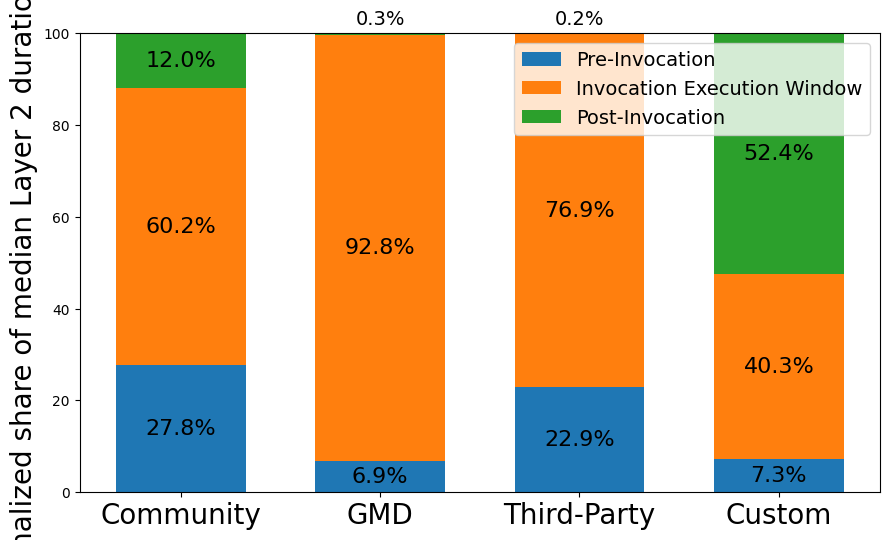

In [25]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
base_dir = Path(r"C:\Android Mobile App\ICST2026_Ext")
input_csv = base_dir / "MainDataset.csv"
output_dir = base_dir / "3.0-Observations"
output_dir.mkdir(parents=True, exist_ok=True)

output_png = output_dir / "rq3_stacked_barchart_layer2_overhead_shares_100.png"
output_pdf = output_dir / "rq3_stacked_barchart_layer2_overhead_shares_100.pdf"

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
if not input_csv.exists():
    raise FileNotFoundError(f"Input file not found: {input_csv}")

df = pd.read_csv(input_csv)

# ------------------------------------------------------------
# Paper Base regime
# Base = instrumentation-executed + first attempt + usable verdict
# ------------------------------------------------------------
required_cols = [
    "style",
    "controller_instru_job_count_gt0",
    "controller_attempt_eq_1",
    "run_conclusion",
    "study_run_duration_seconds",
    "study_pre_invocation_selected_stage3_seconds",
    "study_invocation_execution_window_selected_stage3_seconds",
    "study_post_invocation_selected_stage3_seconds",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Updated order
style_order = ["Community", "GMD", "Third-Party", "Custom"]

base_mask = (
    df["style"].isin(style_order)
    & df["controller_instru_job_count_gt0"].astype(bool)
    & df["controller_attempt_eq_1"].astype(bool)
    & df["run_conclusion"].isin(["success", "failure"])
)

duration_cols = [
    "study_pre_invocation_selected_stage3_seconds",
    "study_invocation_execution_window_selected_stage3_seconds",
    "study_post_invocation_selected_stage3_seconds",
    "study_run_duration_seconds",
]

sub = df.loc[base_mask].copy()
sub = sub.dropna(subset=duration_cols)
sub = sub[sub["study_run_duration_seconds"] > 0].copy()

if sub.empty:
    raise ValueError("No Base-regime rows available after filtering.")

# ------------------------------------------------------------
# Compute median durations by style, then normalize to 100%
# ------------------------------------------------------------
med_dur = (
    sub.groupby("style")[[
        "study_pre_invocation_selected_stage3_seconds",
        "study_invocation_execution_window_selected_stage3_seconds",
        "study_post_invocation_selected_stage3_seconds",
    ]]
    .median()
    .reindex(style_order)
)

med_dur.columns = ["pre_median", "exec_median", "post_median"]

med_dur["sum_median_components"] = (
    med_dur["pre_median"] + med_dur["exec_median"] + med_dur["post_median"]
)

if (med_dur["sum_median_components"] <= 0).any():
    raise ValueError("One or more styles have non-positive summed median components.")

med_dur["pre_pct"] = 100 * med_dur["pre_median"] / med_dur["sum_median_components"]
med_dur["exec_pct"] = 100 * med_dur["exec_median"] / med_dur["sum_median_components"]
med_dur["post_pct"] = 100 * med_dur["post_median"] / med_dur["sum_median_components"]

pre = med_dur["pre_pct"].values
exe = med_dur["exec_pct"].values
post = med_dur["post_pct"].values

# ------------------------------------------------------------
# Print values for verification
# ------------------------------------------------------------
summary_table = med_dur[[
    "pre_median", "exec_median", "post_median",
    "pre_pct", "exec_pct", "post_pct"
]].copy()

summary_table.columns = [
    "Median Pre-Invocation (s)",
    "Median Execution Window (s)",
    "Median Post-Invocation (s)",
    "Pre-Invocation (%)",
    "Execution Window (%)",
    "Post-Invocation (%)",
]

print("\nNormalized Layer 2 composition by style (from median durations):")
print(summary_table.round(1).to_string())

check = (med_dur["pre_pct"] + med_dur["exec_pct"] + med_dur["post_pct"]).round(6)
print("\nBar totals (should be 100):")
print(check.to_string())

# ------------------------------------------------------------
# Plot: true 100% stacked bar chart
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(style_order))
width = 0.65

ax.bar(x, pre, width=width, label="Pre-Invocation")
ax.bar(x, exe, width=width, bottom=pre, label="Invocation Execution Window")
ax.bar(x, post, width=width, bottom=pre + exe, label="Post-Invocation")

ax.set_xticks(x)
ax.set_xticklabels(style_order, fontsize=20)
ax.set_ylabel("Normalized share of median Layer 2 duration (%)", fontsize=20)
ax.set_ylim(0, 100)
ax.legend(frameon=True, fontsize=14)

# Segment labels
for i in range(len(style_order)):
    bottoms = 0
    for val in [pre[i], exe[i], post[i]]:
        if val >= 5:
            ax.text(
                i,
                bottoms + val / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=16
            )
        else:
            ax.text(
                i,
                bottoms + val + 1.0,
                f"{val:.1f}%",
                ha="center",
                va="bottom",
                fontsize=14
            )
        bottoms += val

plt.tight_layout()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
fig.savefig(output_png, dpi=300, bbox_inches="tight")
fig.savefig(output_pdf, bbox_inches="tight")

print(f"\nSaved PNG to: {output_png}")
print(f"Saved PDF to: {output_pdf}")

# ------------------------------------------------------------
# Show plot
# ------------------------------------------------------------
plt.show()

In [12]:
#RQ4 Plots Observations 


RQ4 trigger distribution by style (%):
event_group  push  pull_request  schedule  other
style                                           
Community    88.1           1.7       9.8    0.5
GMD           9.8           0.0      90.2    0.0
Third-Party  12.1           0.0      87.3    0.6
Custom       30.8          66.7       0.0    2.6

Saved trigger chart PNG to: C:\Android Mobile App\ICST2026_Ext\3.0-Observations\rq4_trigger_distribution_by_style_100.png
Saved trigger chart PDF to: C:\Android Mobile App\ICST2026_Ext\3.0-Observations\rq4_trigger_distribution_by_style_100.pdf


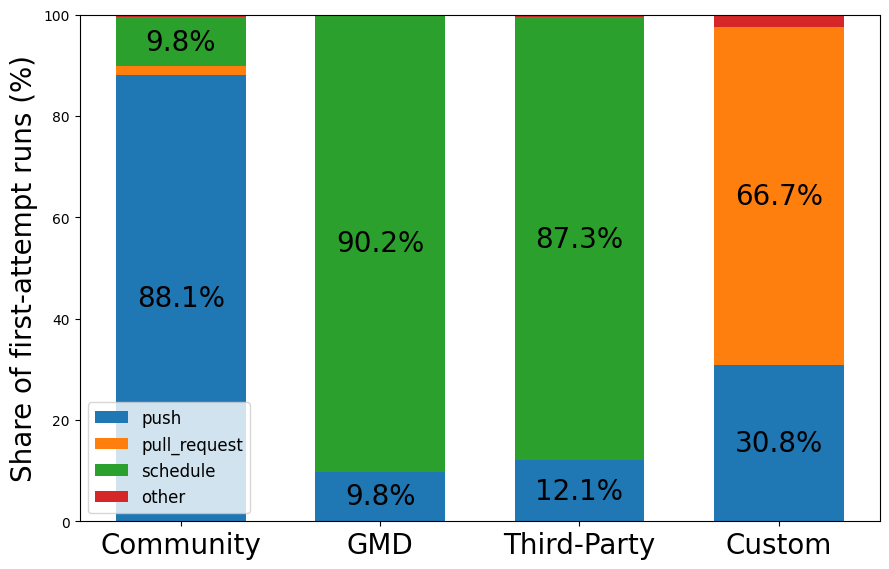


RQ4 success among usable verdicts by style (%):
             usable_flag  success_flag  success_rate_pct
style                                                   
Community           6980          5523              79.1
GMD                  263           258              98.1
Third-Party          526            87              16.5
Custom                34             8              23.5

Saved success chart PNG to: C:\Android Mobile App\ICST2026_Ext\3.0-Observations\rq4_success_among_usable_by_style.png
Saved success chart PDF to: C:\Android Mobile App\ICST2026_Ext\3.0-Observations\rq4_success_among_usable_by_style.pdf


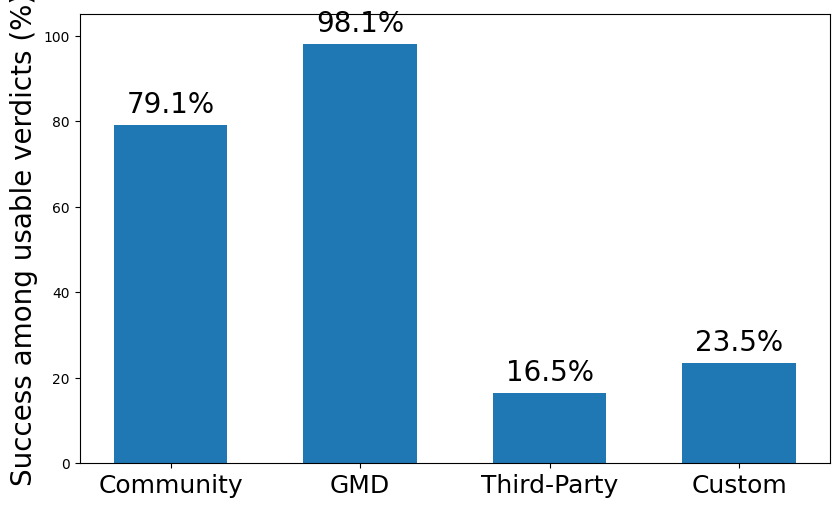

In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
base_dir = Path(r"C:\Android Mobile App\ICST2026_Ext")
input_csv = base_dir / "MainDataset.csv"
output_dir = base_dir / "3.0-Observations"
output_dir.mkdir(parents=True, exist_ok=True)

out_trigger_png = output_dir / "rq4_trigger_distribution_by_style_100.png"
out_trigger_pdf = output_dir / "rq4_trigger_distribution_by_style_100.pdf"

out_success_png = output_dir / "rq4_success_among_usable_by_style.png"
out_success_pdf = output_dir / "rq4_success_among_usable_by_style.pdf"

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
if not input_csv.exists():
    raise FileNotFoundError(f"Input file not found: {input_csv}")

df = pd.read_csv(input_csv)

# ------------------------------------------------------------
# Expected columns
# ------------------------------------------------------------
required_cols = [
    "style",
    "controller_instru_job_count_gt0",
    "controller_attempt_eq_1",
    "run_conclusion",
    "event",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Updated order
style_order = ["Community", "GMD", "Third-Party", "Custom"]

# ------------------------------------------------------------
# RQ4 regime:
# instrumentation-executed first-attempt runs
# (NO usable-verdict restriction for the main regime)
# ------------------------------------------------------------
rq4_mask = (
    df["style"].isin(style_order)
    & df["controller_instru_job_count_gt0"].astype(bool)
    & df["controller_attempt_eq_1"].astype(bool)
)

rq4 = df.loc[rq4_mask].copy()

if rq4.empty:
    raise ValueError("No rows available for the RQ4 first-attempt regime.")

# ------------------------------------------------------------
# Helper: normalize trigger labels a bit for cleaner plots
# ------------------------------------------------------------
rq4["event_clean"] = rq4["event"].fillna("unknown").astype(str).str.strip()

major_events = {"push", "pull_request", "schedule"}
rq4["event_group"] = rq4["event_clean"].apply(
    lambda x: x if x in major_events else "other"
)

event_order = ["push", "pull_request", "schedule", "other"]

# ------------------------------------------------------------
# Plot 1: 100% stacked trigger distribution by style (Obs. 4.3)
# ------------------------------------------------------------
trigger_counts = (
    rq4.groupby(["style", "event_group"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=style_order, columns=event_order, fill_value=0)
)

trigger_pct = trigger_counts.div(trigger_counts.sum(axis=1), axis=0) * 100

print("\nRQ4 trigger distribution by style (%):")
print(trigger_pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 5.8))
x = np.arange(len(style_order))
width = 0.65

bottom = np.zeros(len(style_order))
for event_name in event_order:
    vals = trigger_pct[event_name].values
    ax.bar(x, vals, width=width, bottom=bottom, label=event_name)
    for i, v in enumerate(vals):
        if v >= 6:
            ax.text(i, bottom[i] + v / 2, f"{v:.1f}%", ha="center", va="center", fontsize=20)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(style_order, fontsize=20)
ax.set_ylabel("Share of first-attempt runs (%)", fontsize=20)
ax.set_ylim(0, 100)
ax.legend(frameon=True, fontsize=12)
plt.tight_layout()

fig.savefig(out_trigger_png, dpi=300, bbox_inches="tight")
fig.savefig(out_trigger_pdf, bbox_inches="tight")
print(f"\nSaved trigger chart PNG to: {out_trigger_png}")
print(f"Saved trigger chart PDF to: {out_trigger_pdf}")

plt.show()

# ------------------------------------------------------------
# Plot 2: success rate among usable verdicts by style (Obs. 4.2)
# usable verdict = success or failure
# success among usable = success / (success + failure)
# ------------------------------------------------------------
usable = rq4[rq4["run_conclusion"].isin(["success", "failure"])].copy()

if usable.empty:
    raise ValueError("No usable-verdict rows found inside the RQ4 regime.")

success_summary = (
    usable.assign(
        usable_flag=1,
        success_flag=(usable["run_conclusion"] == "success").astype(int)
    )
    .groupby("style")[["usable_flag", "success_flag"]]
    .sum()
    .reindex(style_order)
)

success_summary["success_rate_pct"] = (
    100 * success_summary["success_flag"] / success_summary["usable_flag"]
)

print("\nRQ4 success among usable verdicts by style (%):")
print(success_summary[["usable_flag", "success_flag", "success_rate_pct"]].round(1).to_string())

fig, ax = plt.subplots(figsize=(8.5, 5.2))
vals = success_summary["success_rate_pct"].values

ax.bar(np.arange(len(style_order)), vals, width=0.6)

for i, v in enumerate(vals):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=20)

ax.set_xticks(np.arange(len(style_order)))
ax.set_xticklabels(style_order, fontsize=18)
ax.set_ylabel("Success among usable verdicts (%)", fontsize=20)
ax.set_ylim(0, 105)

plt.tight_layout()

fig.savefig(out_success_png, dpi=300, bbox_inches="tight")
fig.savefig(out_success_pdf, bbox_inches="tight")
print(f"\nSaved success chart PNG to: {out_success_png}")
print(f"Saved success chart PDF to: {out_success_pdf}")

plt.show()

In [ ]:
#RQ4 Summary Table

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
base_dir = Path(r"C:\Android Mobile App\ICST2026_Ext")
input_csv = base_dir / "MainDataset.csv"
output_dir = base_dir / "3.0-Observations"
output_dir.mkdir(parents=True, exist_ok=True)

out_csv = output_dir / "rq4_summary_table.csv"
out_xlsx = output_dir / "rq4_summary_table.xlsx"
out_md = output_dir / "rq4_summary_table.md"

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
if not input_csv.exists():
    raise FileNotFoundError(f"Input file not found: {input_csv}")

df = pd.read_csv(input_csv)

required_cols = [
    "style",
    "controller_instru_job_count_gt0",
    "controller_attempt_eq_1",
    "run_conclusion",
    "event",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Updated order
style_order = ["Community", "GMD", "Third-Party", "Custom"]

# ------------------------------------------------------------
# RQ4 regime:
# instrumentation-executed first-attempt runs
# ------------------------------------------------------------
rq4_mask = (
    df["style"].isin(style_order)
    & df["controller_instru_job_count_gt0"].astype(bool)
    & df["controller_attempt_eq_1"].astype(bool)
)

rq4 = df.loc[rq4_mask].copy()

if rq4.empty:
    raise ValueError("No rows available for the RQ4 first-attempt regime.")

rq4["event_clean"] = rq4["event"].fillna("unknown").astype(str).str.strip()
major_events = {"push", "pull_request", "schedule"}
rq4["event_group"] = rq4["event_clean"].apply(
    lambda x: x if x in major_events else "other"
)

# ------------------------------------------------------------
# Usable verdict rate
# usable verdict = success or failure
# ------------------------------------------------------------
rq4["usable_flag"] = rq4["run_conclusion"].isin(["success", "failure"]).astype(int)
rq4["success_flag"] = (rq4["run_conclusion"] == "success").astype(int)

summary = (
    rq4.groupby("style")[["usable_flag", "success_flag"]]
       .agg(
           total_runs=("usable_flag", "size"),
           usable_verdicts=("usable_flag", "sum"),
           successes=("success_flag", "sum"),
       )
       .reindex(style_order)
)

summary["usable_verdict_rate_pct"] = 100 * summary["usable_verdicts"] / summary["total_runs"]

# ------------------------------------------------------------
# Success among usable verdicts
# ------------------------------------------------------------
summary["success_among_usable_pct"] = np.where(
    summary["usable_verdicts"] > 0,
    100 * summary["successes"] / summary["usable_verdicts"],
    np.nan
)

# ------------------------------------------------------------
# Dominant trigger
# ------------------------------------------------------------
trigger_counts = (
    rq4.groupby(["style", "event_group"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=style_order, fill_value=0)
)

dominant_trigger = trigger_counts.idxmax(axis=1)
dominant_trigger_share_pct = (
    100 * trigger_counts.max(axis=1) / trigger_counts.sum(axis=1)
)

summary["dominant_trigger"] = dominant_trigger
summary["dominant_trigger_share_pct"] = dominant_trigger_share_pct.round(1)

# ------------------------------------------------------------
# Short profile reading
# ------------------------------------------------------------
def profile_reading(style):
    if style == "Community":
        return "Push-oriented; usable verdicts lower than GMD/Third-Party; healthier success than Custom/Third-Party."
    if style == "GMD":
        return "Schedule-oriented; strongest usable-verdict and success profile."
    if style == "Third-Party":
        return "Schedule-oriented; high usable-verdict rate but strongly failure-dominant among usable outcomes."
    if style == "Custom":
        return "Pull-request-oriented; lower usable-verdict and success profile; interpret cautiously."
    return ""

summary["profile_reading"] = [profile_reading(s) for s in summary.index]

# ------------------------------------------------------------
# Final compact table
# ------------------------------------------------------------
final_cols = [
    "usable_verdict_rate_pct",
    "success_among_usable_pct",
    "dominant_trigger",
    "dominant_trigger_share_pct",
    "profile_reading",
]

final_table = summary[final_cols].copy()
final_table.columns = [
    "Usable verdict rate (%)",
    "Success among usable (%)",
    "Dominant trigger",
    "Dominant trigger share (%)",
    "Profile reading",
]

print("\nCompact RQ4 summary table:")
print(final_table.round(1).to_string())

# ------------------------------------------------------------
# Optional: save markdown without requiring tabulate
# ------------------------------------------------------------
def dataframe_to_markdown(df: pd.DataFrame) -> str:
    cols = list(df.columns)
    header = "| style | " + " | ".join(cols) + " |"
    sep = "|---" * (len(cols) + 1) + "|"
    rows = []
    for idx, row in df.iterrows():
        vals = [str(row[c]) for c in cols]
        rows.append("| " + str(idx) + " | " + " | ".join(vals) + " |")
    return "\n".join([header, sep] + rows)

# Save files
rounded = final_table.round(1)
rounded.to_csv(out_csv)
rounded.to_excel(out_xlsx)
out_md.write_text(dataframe_to_markdown(rounded), encoding="utf-8")

print(f"\nSaved CSV to: {out_csv}")
print(f"Saved XLSX to: {out_xlsx}")
print(f"Saved Markdown to: {out_md}")


Compact RQ4 summary table:
             Usable verdict rate (%)  Success among usable (%) Dominant trigger  Dominant trigger share (%)                                                                                        Profile reading
style                                                                                                                                                                                                             
Community                       89.2                      79.1             push                        88.1  Push-oriented; usable verdicts lower than GMD/Third-Party; healthier success than Custom/Third-Party.
GMD                             99.2                      98.1         schedule                        90.2                                       Schedule-oriented; strongest usable-verdict and success profile.
Third-Party                     98.1                      16.5         schedule                        87.3       Schedule-orien